<h3> <b>Project Based Virtual Intern: Data Scientist ID/X Partners x Rakamin Academy

Author: Arga Bathara

Date: 3 August 2025

<h1> <b>Credit Risk Prediction

## <b>Introduction

Acting as a Data Scientist at ID/X Partners, this project aims to assist a multifinance client in enhancing their credit risk assessment and management. The main objective is to develop a machine learning model capable of predicting credit risk based on a provided dataset of historical loans, which includes both approved and rejected applications. An accurate predictive model will help the client optimize business decisions and minimize potential financial losses.

The model development process will follow these core steps:
* Data Understanding
* Exploratory Data Analysis (EDA)
* Data Preparation
* Data Modeling
* Evaluation

---

## <b>Preparing the Enviroment

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [105]:
df = pd.read_csv('dataset/loan_data_2007_2014.csv', low_memory=False)

---

## <b>Data Understanding

In [106]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

<b>Insight:</b> The dataset contains 466,285 rows and 75 columns, consisting of integer, float, and object data types.

### <b> Feature Engineering

<b> Defining target variabel

Examining the data quality of the target variable's determinants.

In [108]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [109]:
loan_status_percentages = df['loan_status'].value_counts(normalize=True) * 100
print(loan_status_percentages)

loan_status
Current                                                48.087757
Fully Paid                                             39.619332
Charged Off                                             9.109236
Late (31-120 days)                                      1.479782
In Grace Period                                         0.674695
Does not meet the credit policy. Status:Fully Paid      0.426349
Late (16-30 days)                                       0.261214
Default                                                 0.178432
Does not meet the credit policy. Status:Charged Off     0.163205
Name: proportion, dtype: float64


In [110]:
df['acc_now_delinq'].unique()

array([ 0.,  1., nan,  2.,  3.,  5.,  4.])

In [111]:
df['acc_now_delinq'] = df['acc_now_delinq'].fillna(0)
df['acc_now_delinq'].unique()

array([0., 1., 2., 3., 5., 4.])

In [112]:
acc_now_deling_percentages = df['acc_now_delinq'].value_counts(normalize=True) * 100
print(acc_now_deling_percentages)

acc_now_delinq
0.0    99.628553
1.0     0.348070
2.0     0.019730
3.0     0.002359
4.0     0.000858
5.0     0.000429
Name: proportion, dtype: float64


In [113]:
df['pub_rec'].unique()

array([ 0.,  1.,  2.,  3.,  4.,  5., nan,  6.,  9.,  8.,  7., 11., 49.,
       10., 54., 12., 18., 19., 16., 15., 14., 40., 63., 13., 21., 34.,
       17.])

In [114]:
df['pub_rec'] = df['pub_rec'].fillna(0)
df['pub_rec'].unique()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  9.,  8.,  7., 11., 49., 10.,
       54., 12., 18., 19., 16., 15., 14., 40., 63., 13., 21., 34., 17.])

In [115]:
pub_rec_percentages = df['pub_rec'].value_counts(normalize=True) * 100
print(pub_rec_percentages)

pub_rec
0.0     86.840023
1.0     11.377376
2.0      1.206129
3.0      0.345497
4.0      0.111520
5.0      0.059191
6.0      0.029167
7.0      0.013297
8.0      0.006219
9.0      0.003431
10.0     0.002788
11.0     0.001716
12.0     0.000429
18.0     0.000429
13.0     0.000429
40.0     0.000214
34.0     0.000214
21.0     0.000214
63.0     0.000214
54.0     0.000214
14.0     0.000214
15.0     0.000214
16.0     0.000214
19.0     0.000214
49.0     0.000214
17.0     0.000214
Name: proportion, dtype: float64


To establish the primary goal of the analysis, we define the target variable by creating a new `credit_risk` column. The default risk is set to 'Bad', and a borrower is only classified as 'Good' if they meet all of the following criteria:

* **`loan_status` is in good standing:** The status is Fully Paid, Current, In Grace Period, or 'Does not meet the credit policy. Status:Fully Paid'. This shows a reliable payment history.
* **`acc_now_delinq` is 0:** The borrower has no active overdue accounts.
* **`pub_rec` is 0:** The borrower has no negative public records like bankruptcies or legal trouble.

In [116]:
df['credit_risk'] = 'bad'

good_credit_criteria = (
    (df['loan_status'].isin([
        'Fully Paid', 
        'Current',
        'In Grace Period',
        'Does Not Meet the Credit Policy. Status: Fully Paid',
        ])) &
    (df['acc_now_delinq'] == 0) &
    (df['pub_rec'] == 0)
)

df.loc[good_credit_criteria, 'credit_risk'] = 'good'
df[['loan_status', 'acc_now_delinq', 'pub_rec', 'credit_risk']].head(10)

,loan_status,acc_now_delinq,pub_rec,credit_risk
0,Fully Paid,0.0,0.0,good
1,Charged Off,0.0,0.0,bad
2,Fully Paid,0.0,0.0,good
3,Fully Paid,0.0,0.0,good
4,Current,0.0,0.0,good
5,Fully Paid,0.0,0.0,good
6,Current,0.0,0.0,good
7,Fully Paid,0.0,0.0,good
8,Charged Off,0.0,0.0,bad
9,Charged Off,0.0,0.0,bad


<b> Data Cleaning

Dropping irrelevant columns

In [117]:
if df['id'].is_unique and df['member_id'].is_unique:
    print("The 'id' and 'member_id' columns are unique identifiers.")
else:
    print("The 'id' and 'member_id' columns are not unique identifiers.")

The 'id' and 'member_id' columns are unique identifiers.


In [ ]:
cols_to_drop = [
    
    # Unique identifiers
    'Unnamed: 0',
    'id',
    'member_id',
    
    # Free text
    'url',
    'desc',
    
    # All null/constant/others
    'zip_code',
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'open_acc_6m',
    'open_il_6m',
    'open_il_12m',
    'open_il_24m',
    'mths_since_rcnt_il',
    'total_bal_il',
    'il_util',
    'open_rv_12m',
    'open_rv_24m',
    'max_bal_bc',
    'all_util',
    'inq_fi',
    'total_cu_tl',
    'inq_last_12m',
    'mths_since_last_major_derog',
    'tot_coll_amt',
    'tot_cur_bal',
    'total_rev_hi_lim',
    'emp_title',
    'title',
    'application_type',
    'policy_code',
    'sub_grade'
]

df.drop(columns=cols_to_drop, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   funded_amnt                 466285 non-null  int64  
 2   funded_amnt_inv             466285 non-null  float64
 3   term                        466285 non-null  object 
 4   int_rate                    466285 non-null  float64
 5   installment                 466285 non-null  float64
 6   grade                       466285 non-null  object 
 7   emp_length                  445277 non-null  object 
 8   home_ownership              466285 non-null  object 
 9   annual_inc                  466281 non-null  float64
 10  verification_status         466285 non-null  object 
 11  issue_d                     466285 non-null  object 
 12  loan_status                 466285 non-null  object 
 13  pymnt_plan    

Cleaning columns:

```delinq_2yrs```

In [119]:
df['delinq_2yrs'].unique()

array([ 0.,  2.,  3.,  1.,  4.,  6.,  5.,  8.,  7.,  9., 11., nan, 13.,
       15., 10., 12., 17., 18., 29., 24., 14., 21., 22., 19., 16.])

The maximum value in this column should be 24. The number 29 was found in the initial data, so it needs to be corrected to 24.

In [120]:
df.loc[df['delinq_2yrs'] == 29, 'delinq_2yrs'] = 24
df['delinq_2yrs'].unique()

array([ 0.,  2.,  3.,  1.,  4.,  6.,  5.,  8.,  7.,  9., 11., nan, 13.,
       15., 10., 12., 17., 18., 24., 14., 21., 22., 19., 16.])

```Column emp_length```

In [121]:
df['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

Simplifying column data.

In [122]:
df['emp_length_int'] = df['emp_length'].str.replace(r'[^0-9]+', '', regex=True).astype(float)
df['emp_length_int'].unique()

array([10.,  1.,  3.,  8.,  9.,  4.,  5.,  6.,  2.,  7., nan])

In [123]:
df.drop(columns=['emp_length'], inplace=True)

```Column term_int```

In [124]:
unique_terms = df['term'].unique()
print(unique_terms)

[' 36 months' ' 60 months']


Simplifying column data.

In [125]:
df['term_int'] = df['term'].str.replace('months', '').astype(float)

unique_terms = df['term_int'].unique()
print(unique_terms)

[36. 60.]


In [126]:
df.drop(columns=['term'], inplace=True)

```Column earliest_cr_line```

In [127]:
df['earliest_cr_line'].head()

0    Jan-85
1    Apr-99
2    Nov-01
3    Feb-96
4    Jan-96
Name: earliest_cr_line, dtype: object

In [128]:
df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y')
df['earliest_cr_line_date'].head()

0   1985-01-01
1   1999-04-01
2   2001-11-01
3   1996-02-01
4   1996-01-01
Name: earliest_cr_line_date, dtype: datetime64[ns]

Create a column showing the months since the borrower's first credit opened.

In [129]:
ref_date = pd.to_datetime('2017-12-01')

df['mths_since_last_cr_line'] = (ref_date.year - df['earliest_cr_line_date'].dt.year) * 12 + (ref_date.month - df['earliest_cr_line_date'].dt.month)
df['mths_since_last_cr_line'].head()

0    395.0
1    224.0
2    193.0
3    262.0
4    263.0
Name: mths_since_last_cr_line, dtype: float64

In [130]:
df['mths_since_last_cr_line'].describe()

count    466256.000000
mean        239.482430
std          93.974829
min        -612.000000
25%         183.000000
50%         225.000000
75%         285.000000
max         587.000000
Name: mths_since_last_cr_line, dtype: float64

In [131]:
df[df['mths_since_last_cr_line'] < 0][['earliest_cr_line', 'earliest_cr_line_date', 'mths_since_last_cr_line']].head()

,earliest_cr_line,earliest_cr_line_date,mths_since_last_cr_line
1580,Sep-62,2062-09-01,-537.0
1770,Sep-68,2068-09-01,-609.0
2799,Sep-64,2064-09-01,-561.0
3282,Sep-67,2067-09-01,-597.0
3359,Feb-65,2065-02-01,-566.0


Negative values appeared because Python misinterpreted the year '62' as 2062 instead of 1962. These negative values are replaced with the maximum value of the feature, which makes sense since they represent older data from the 1900s.

In [132]:
df.loc[df['mths_since_last_cr_line'] < 0, 'mths_since_last_cr_line'] = df['mths_since_last_cr_line'].max()
df['mths_since_last_cr_line'].describe()

count    466256.000000
mean        242.385374
std          86.460310
min          73.000000
25%         184.000000
50%         226.000000
75%         285.000000
max         587.000000
Name: mths_since_last_cr_line, dtype: float64

In [133]:
df.drop(columns=['earliest_cr_line', 'earliest_cr_line_date'], inplace=True)

```Column issue_d```

In [134]:
df['issue_d'].head()

0    Dec-11
1    Dec-11
2    Dec-11
3    Dec-11
4    Dec-11
Name: issue_d, dtype: object

In [135]:
df['issue_d_date'] = pd.to_datetime(df['issue_d'], format='%b-%y')
df['issue_d_date'].head()

0   2011-12-01
1   2011-12-01
2   2011-12-01
3   2011-12-01
4   2011-12-01
Name: issue_d_date, dtype: datetime64[ns]

Create a column showing the months since the borrower's loan was funded.

In [136]:
df['mths_since_last_issue_d'] = (ref_date.year - df['issue_d_date'].dt.year) * 12 + (ref_date.month - df['issue_d_date'].dt.month)
df['mths_since_last_issue_d'].describe()

count    466285.000000
mean         51.255187
std          14.340154
min          36.000000
25%          41.000000
50%          47.000000
75%          57.000000
max         126.000000
Name: mths_since_last_issue_d, dtype: float64

In [137]:
df.drop(columns=['issue_d', 'issue_d_date'], inplace=True)

```Column last_pymnt_d```

In [138]:
df['last_pymnt_d'].head()

0    Jan-15
1    Apr-13
2    Jun-14
3    Jan-15
4    Jan-16
Name: last_pymnt_d, dtype: object

In [139]:
df['last_pymnt_d_date'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%y')
df['last_pymnt_d_date'].head()

0   2015-01-01
1   2013-04-01
2   2014-06-01
3   2015-01-01
4   2016-01-01
Name: last_pymnt_d_date, dtype: datetime64[ns]

Create a column showing the months since the borrower's last payment.

In [140]:
df['mths_since_last_pymnt_d'] = (ref_date.year - df['last_pymnt_d_date'].dt.year) * 12 + (ref_date.month - df['last_pymnt_d_date'].dt.month)
df['mths_since_last_pymnt_d'].describe()

count    465909.000000
mean         31.294369
std          12.809898
min          23.000000
25%          23.000000
50%          24.000000
75%          35.000000
max         120.000000
Name: mths_since_last_pymnt_d, dtype: float64

In [141]:
df.drop(columns=['last_pymnt_d', 'last_pymnt_d_date'], inplace=True)

```Column next_pymnt_d```

In [142]:
df['next_pymnt_d'].head()

0       NaN
1       NaN
2       NaN
3       NaN
4    Feb-16
Name: next_pymnt_d, dtype: object

Create a column showing the months since the borrower's next payment.

In [143]:
df['next_pymnt_d_date'] = pd.to_datetime(df['next_pymnt_d'], format='%b-%y')
df['mths_since_next_pymnt_d'] = (ref_date.year - df['next_pymnt_d_date'].dt.year) * 12 + (ref_date.month - df['next_pymnt_d_date'].dt.month)

In [144]:
df['mths_since_next_pymnt_d'].describe()

count    239071.000000
mean         22.738136
std           6.082298
min          21.000000
25%          22.000000
50%          22.000000
75%          22.000000
max         120.000000
Name: mths_since_next_pymnt_d, dtype: float64

In [145]:
df.drop(columns=['next_pymnt_d', 'next_pymnt_d_date'], inplace=True)

```Column last_credit_pull_d```

In [146]:
df['last_credit_pull_d'].head()

0    Jan-16
1    Sep-13
2    Jan-16
3    Jan-15
4    Jan-16
Name: last_credit_pull_d, dtype: object

Create a column showing the months since the borrower's last credit pull.

In [147]:
df['last_credit_pull_d_date'] = pd.to_datetime(df['last_credit_pull_d'], format='%b-%y')
df['mths_since_last_credit_pull_d'] = (ref_date.year - df['last_credit_pull_d_date'].dt.year) * 12 + (ref_date.month - df['last_credit_pull_d_date'].dt.month)

In [148]:
df['mths_since_last_credit_pull_d'].describe()

count    466243.000000
mean         27.045588
std           9.636423
min          23.000000
25%          23.000000
50%          23.000000
75%          25.000000
max         127.000000
Name: mths_since_last_credit_pull_d, dtype: float64

In [149]:
df.drop(columns=['last_credit_pull_d', 'last_credit_pull_d_date'], inplace=True)

---

### <b> Exploratory Data Analysis (EDA)

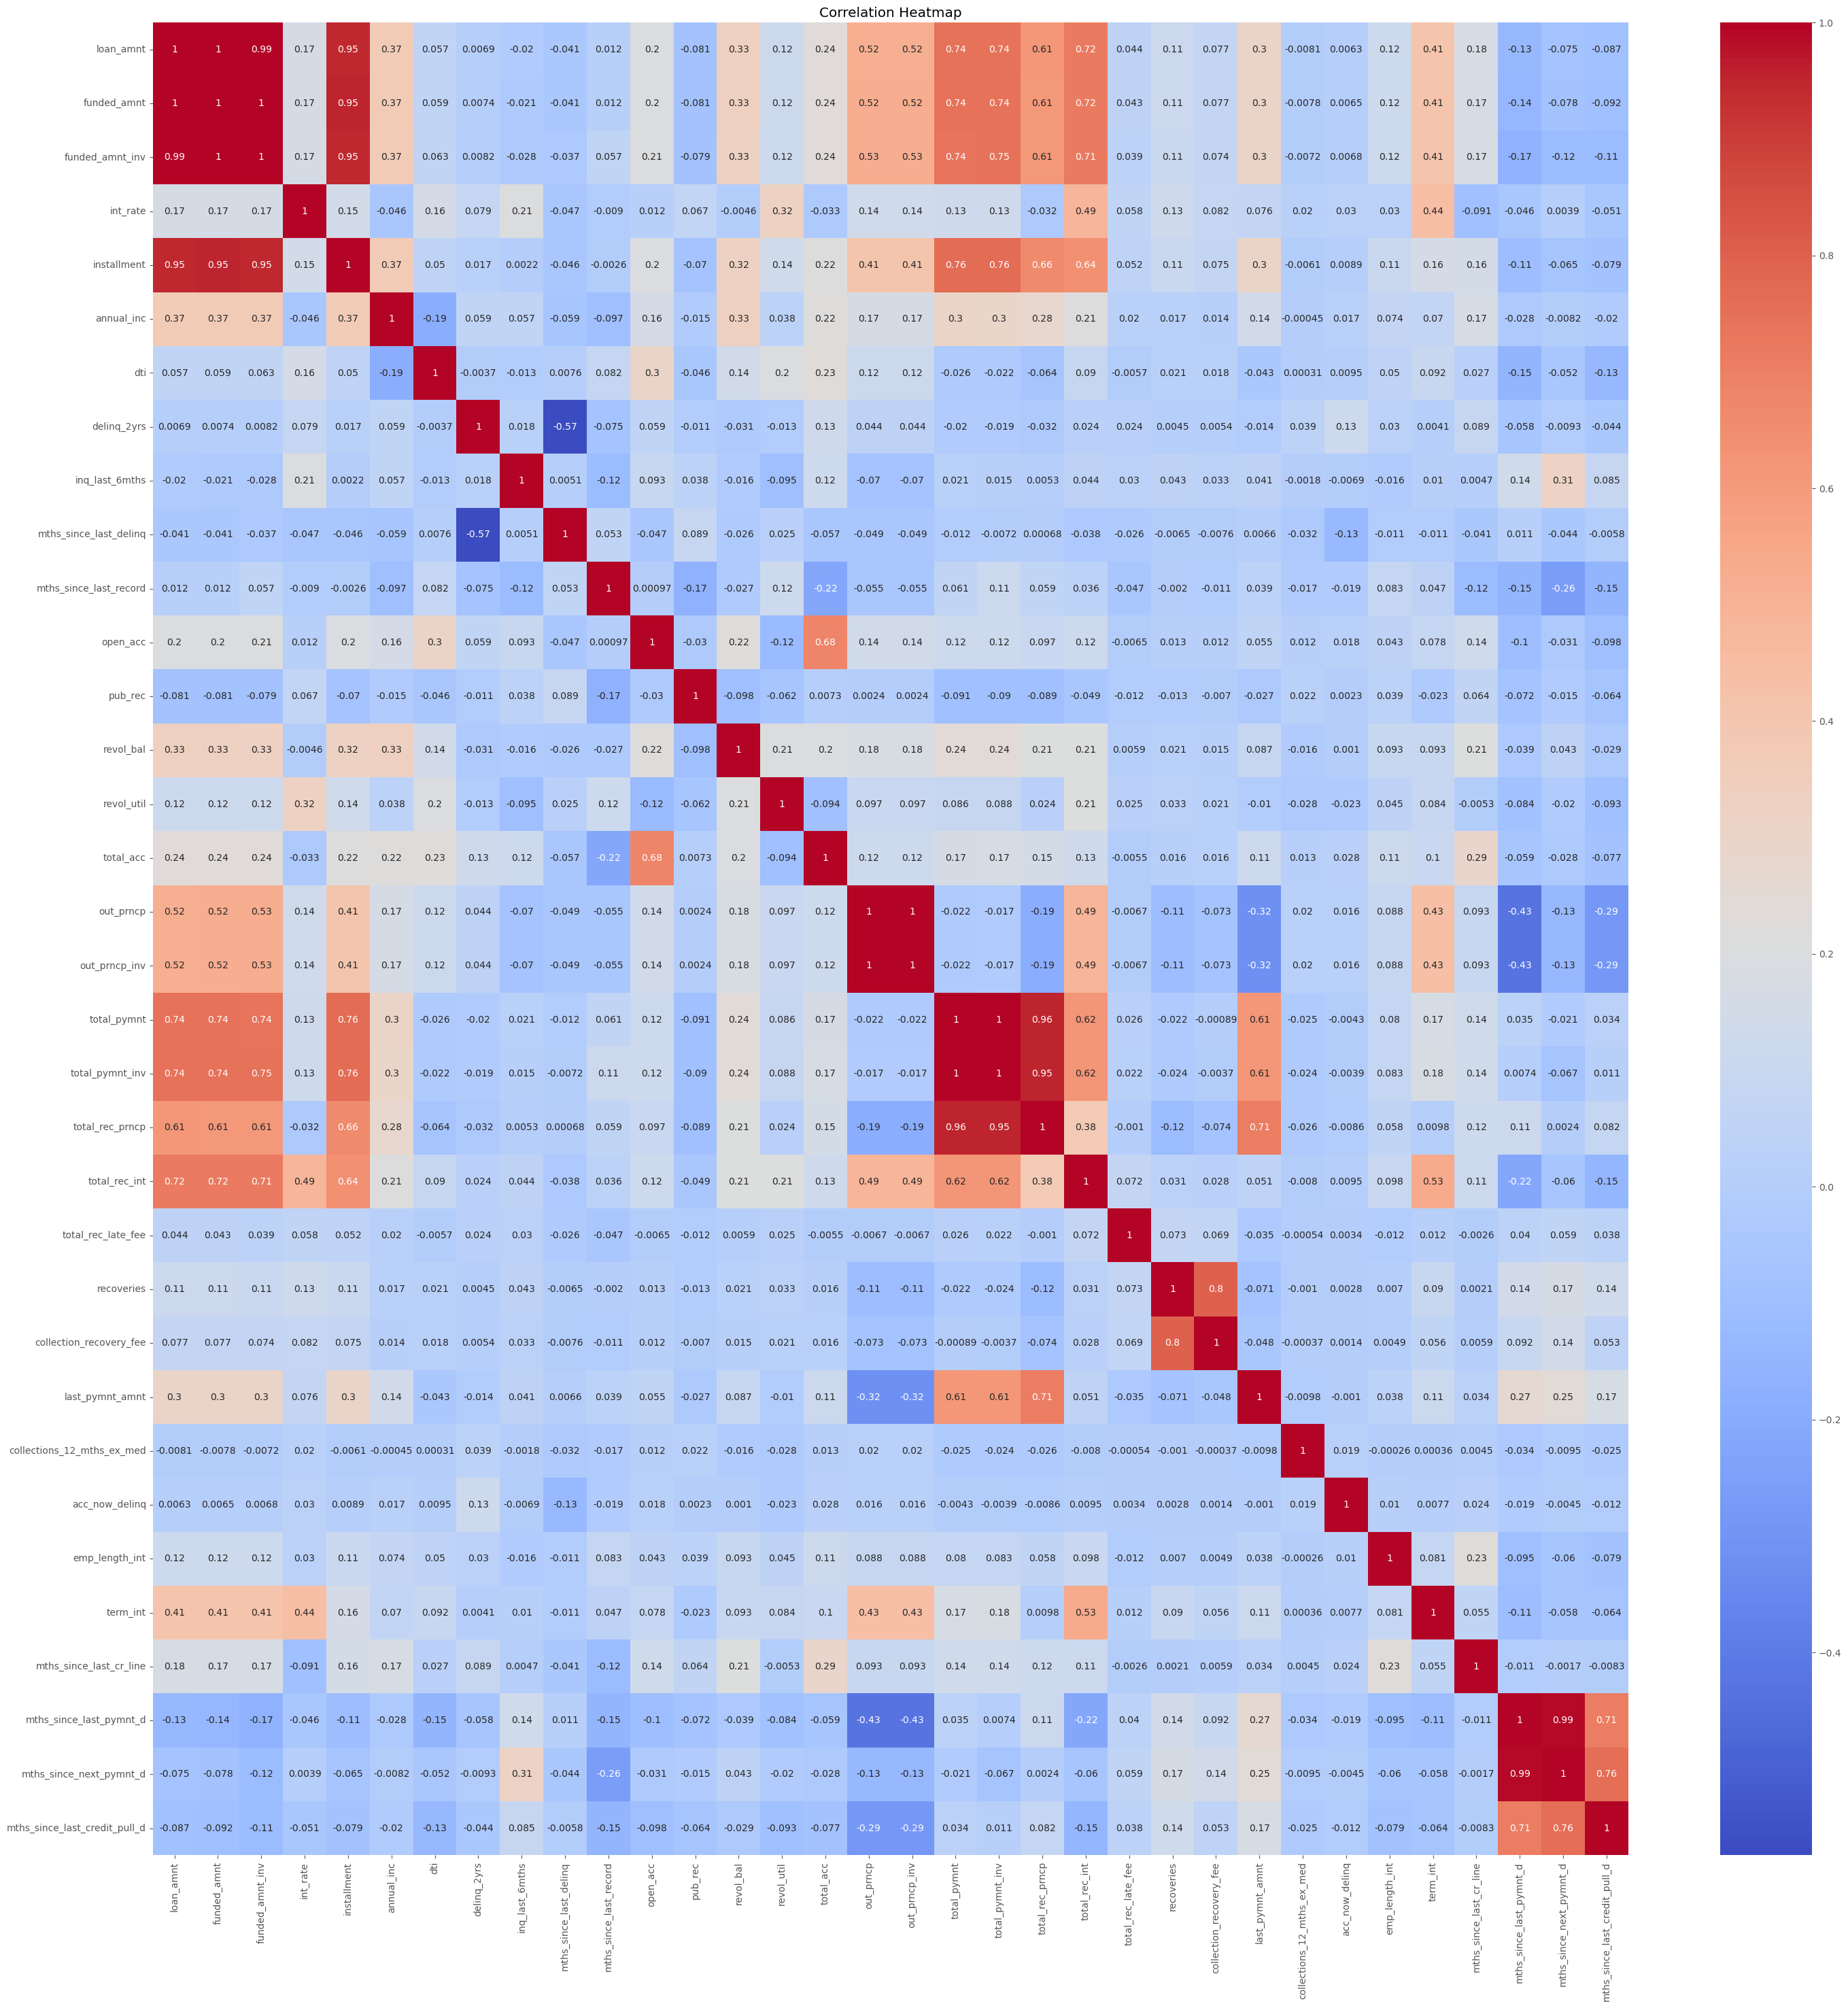

In [150]:
matrix = df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(35, 35))
sns.heatmap(matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [151]:
df.select_dtypes(include=['float64', 'int64']).nunique()

loan_amnt                          1352
funded_amnt                        1354
funded_amnt_inv                    9854
int_rate                            506
installment                       55622
annual_inc                        31901
dti                                3997
delinq_2yrs                          23
inq_last_6mths                       28
mths_since_last_delinq              145
mths_since_last_record              123
open_acc                             62
pub_rec                              26
revol_bal                         58142
revol_util                         1269
total_acc                           112
out_prncp                        135665
out_prncp_inv                    141189
total_pymnt                      351609
total_pymnt_inv                  347659
total_rec_prncp                  172713
total_rec_int                    270249
total_rec_late_fee                 5808
recoveries                        22773
collection_recovery_fee           20275


In [152]:
df.select_dtypes(include=['object']).nunique()

grade                   7
home_ownership          6
verification_status     3
loan_status             9
pymnt_plan              2
purpose                14
addr_state             50
initial_list_status     2
credit_risk             2
dtype: int64

In [153]:
for col in df.select_dtypes(include=['object']).columns.to_list():
    print(df[col].value_counts(normalize=True)*100)
    print("\n")

grade
B    29.365946
C    26.870476
D    16.489486
A    16.056060
E     7.668486
F     2.837106
G     0.712440
Name: proportion, dtype: float64


home_ownership
MORTGAGE    50.586015
RENT        40.420129
OWN          8.943886
OTHER        0.039032
NONE         0.010723
ANY          0.000214
Name: proportion, dtype: float64


verification_status
Verified           36.041262
Source Verified    32.167666
Not Verified       31.791072
Name: proportion, dtype: float64


loan_status
Current                                                48.087757
Fully Paid                                             39.619332
Charged Off                                             9.109236
Late (31-120 days)                                      1.479782
In Grace Period                                         0.674695
Does not meet the credit policy. Status:Fully Paid      0.426349
Late (16-30 days)                                       0.261214
Default                                                 0.17843

In [154]:
df.drop(columns=['pymnt_plan'], inplace=True)

In [155]:
cat_df = df.select_dtypes(include=['object']).columns
print(cat_df)

Index(['grade', 'home_ownership', 'verification_status', 'loan_status',
       'purpose', 'addr_state', 'initial_list_status', 'credit_risk'],
      dtype='object')


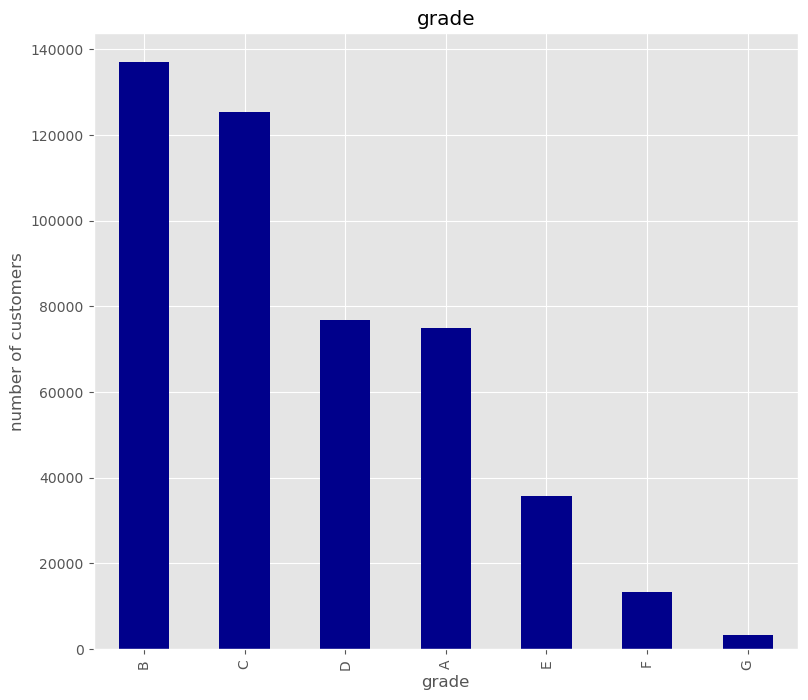

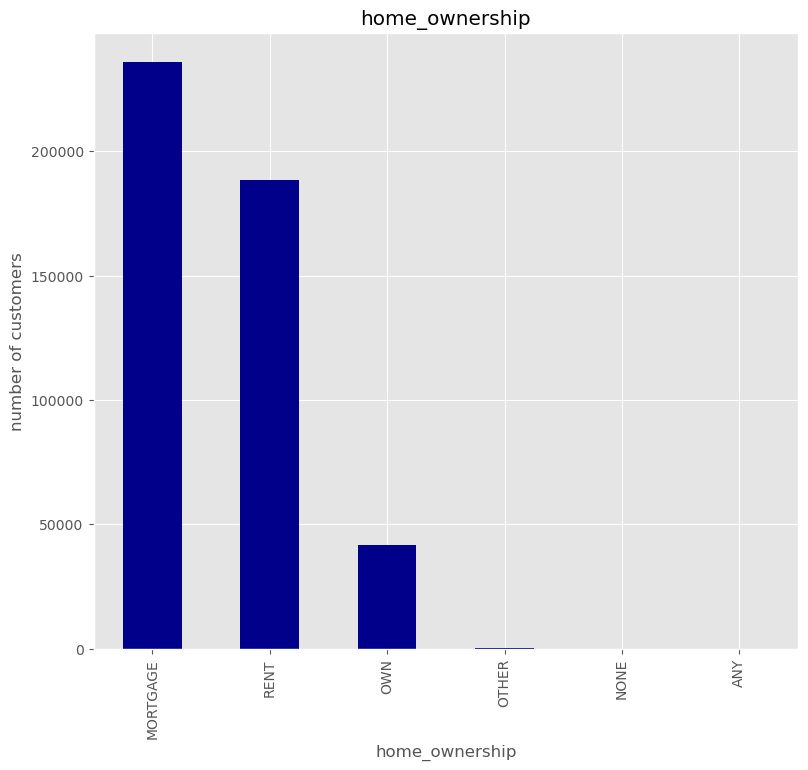

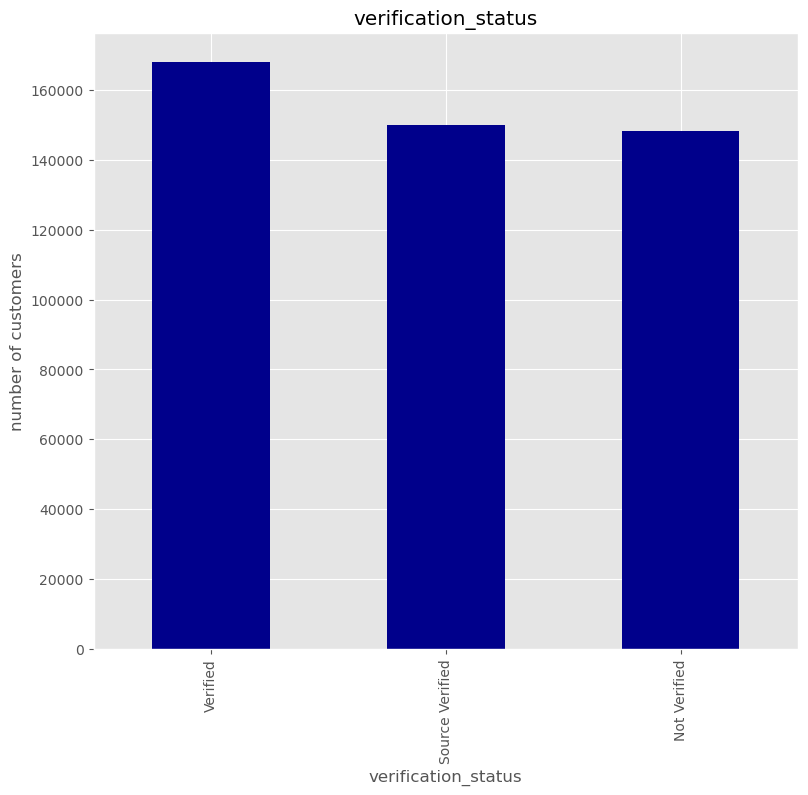

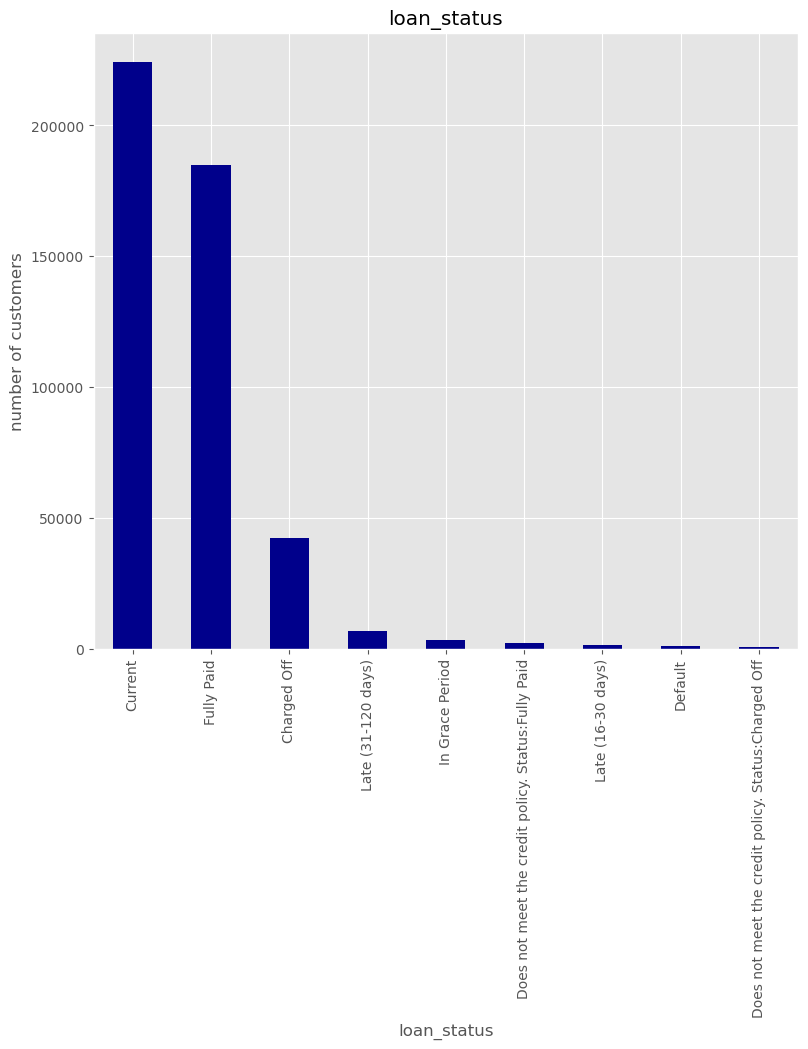

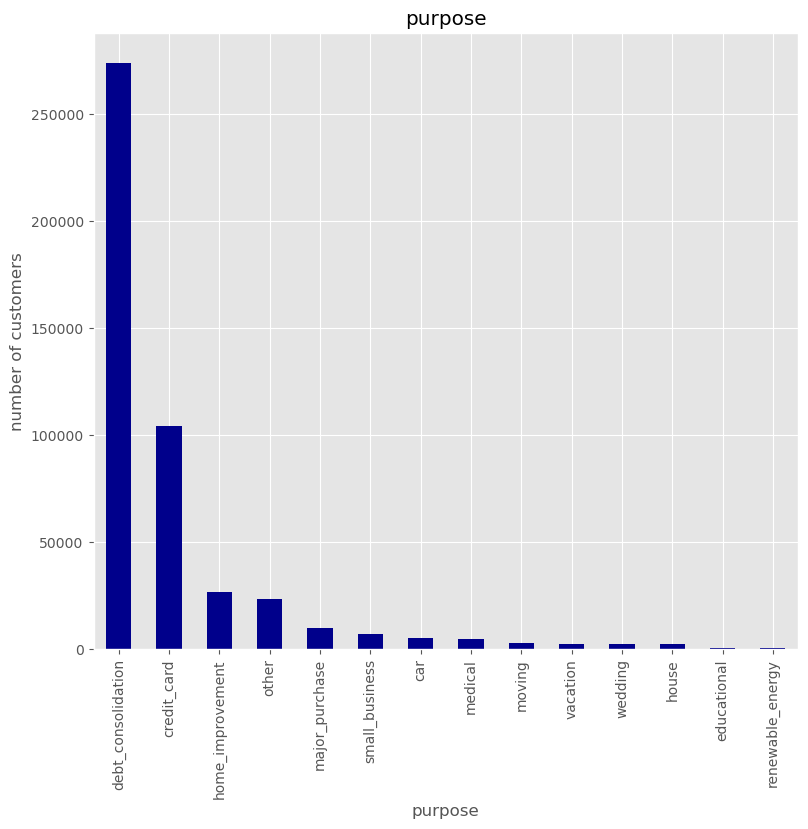

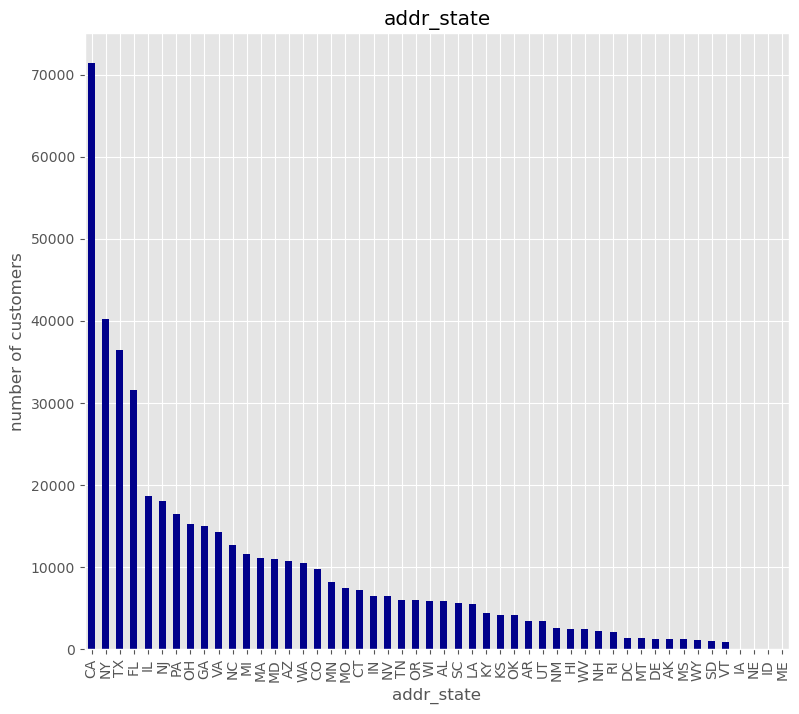

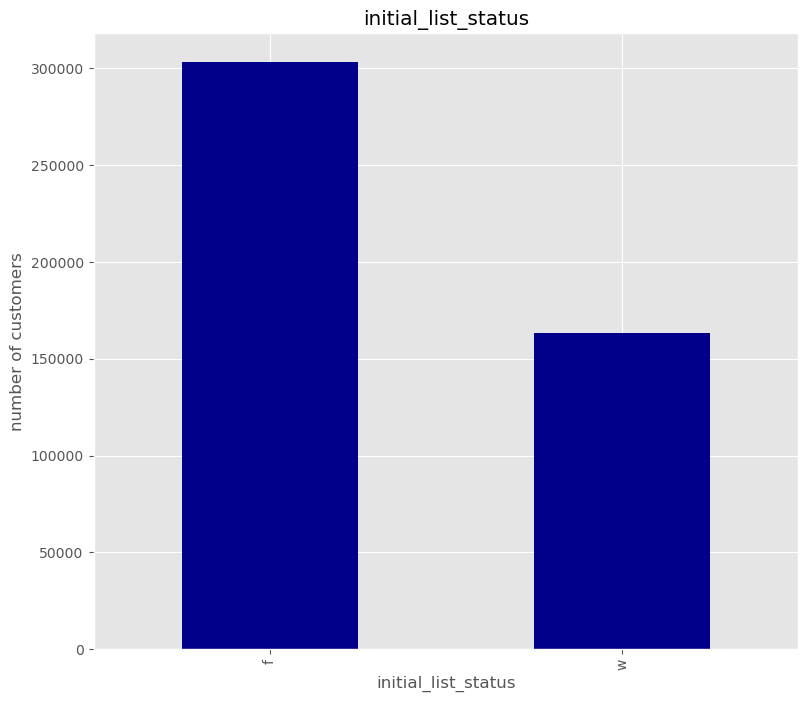

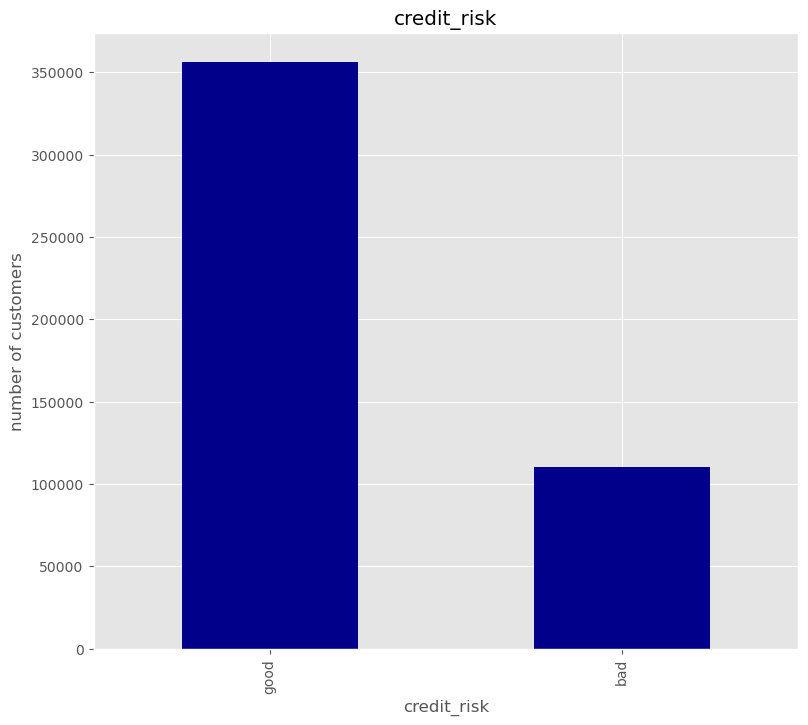

In [156]:
for column in cat_df:
    plt.figure(figsize=(20, 8))
    plt.subplot(121)
    df[column].value_counts().plot(kind='bar', color='darkblue')
    plt.xlabel(column)
    plt.ylabel('number of customers')
    plt.title(column)

In [157]:
num_df = df.select_dtypes(include=np.number)
num_df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,...,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,emp_length_int,term_int,mths_since_last_cr_line,mths_since_last_issue_d,mths_since_last_pymnt_d,mths_since_next_pymnt_d,mths_since_last_credit_pull_d
0,5000,5000,4975.0,10.65,162.87,24000.0,27.65,0.0,1.0,NaN,...,171.62,0.0,0.0,10.0,36.0,395.0,72,35.0,NaN,23.0
1,2500,2500,2500.0,15.27,59.83,30000.0,1.00,0.0,5.0,NaN,...,119.66,0.0,0.0,1.0,60.0,224.0,72,56.0,NaN,51.0
2,2400,2400,2400.0,15.96,84.33,12252.0,8.72,0.0,2.0,NaN,...,649.91,0.0,0.0,10.0,36.0,193.0,72,42.0,NaN,23.0
3,10000,10000,10000.0,13.49,339.31,49200.0,20.00,0.0,1.0,35.0,...,357.48,0.0,0.0,10.0,36.0,262.0,72,35.0,NaN,35.0
4,3000,3000,3000.0,12.69,67.79,80000.0,17.94,0.0,0.0,38.0,...,67.79,0.0,0.0,1.0,60.0,263.0,72,23.0,22.0,23.0


D:\R\Rtemp\ipykernel_20404\3630302382.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20, 8))


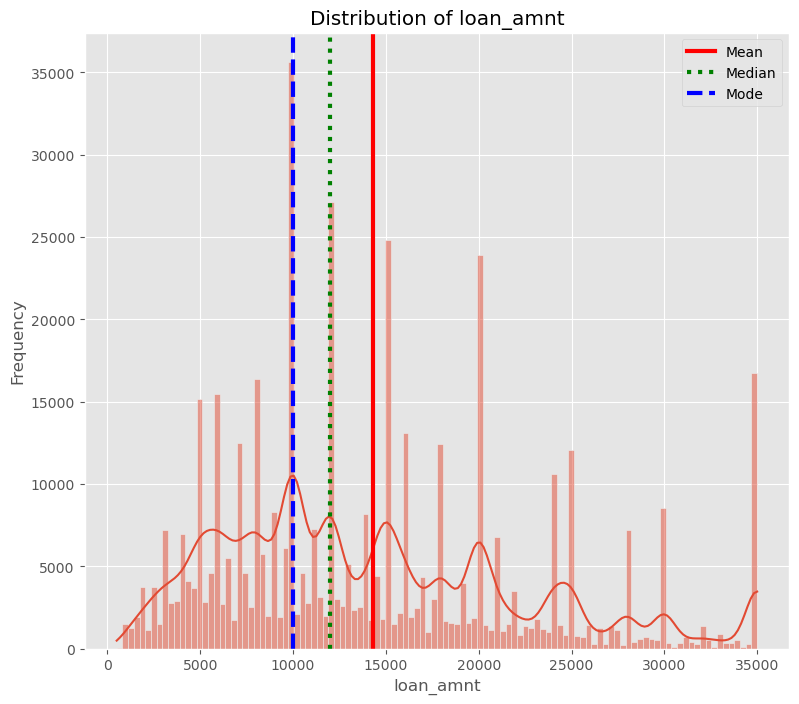

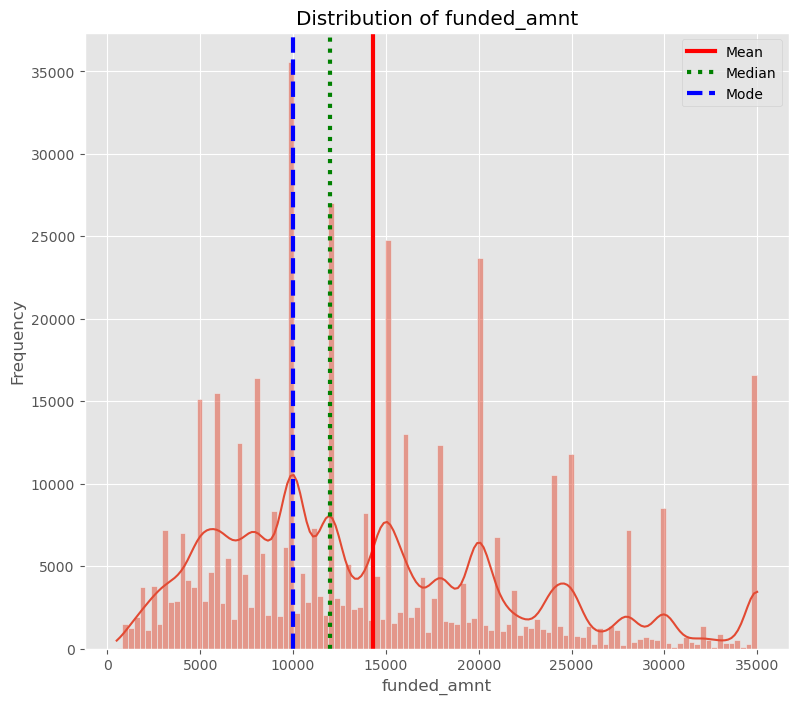

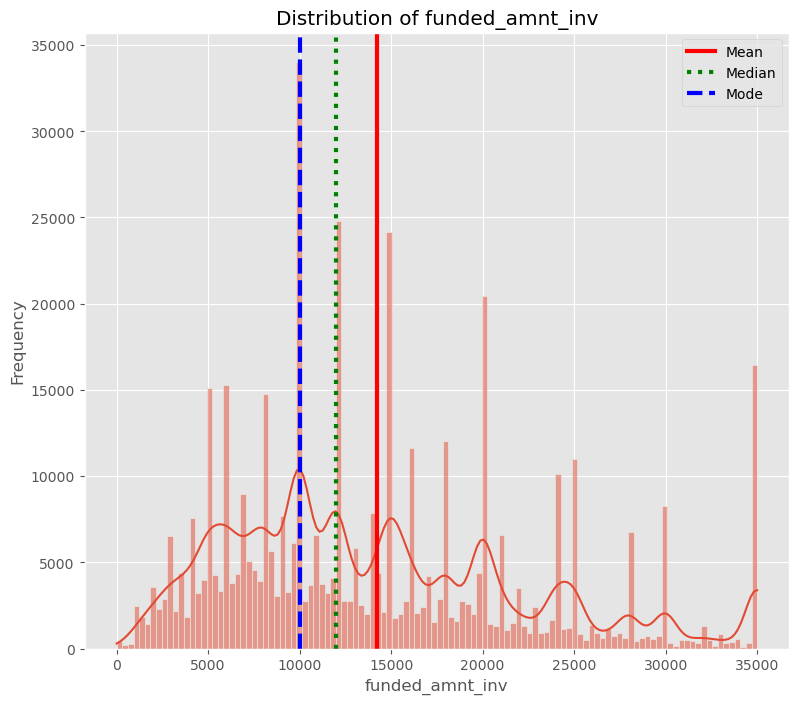

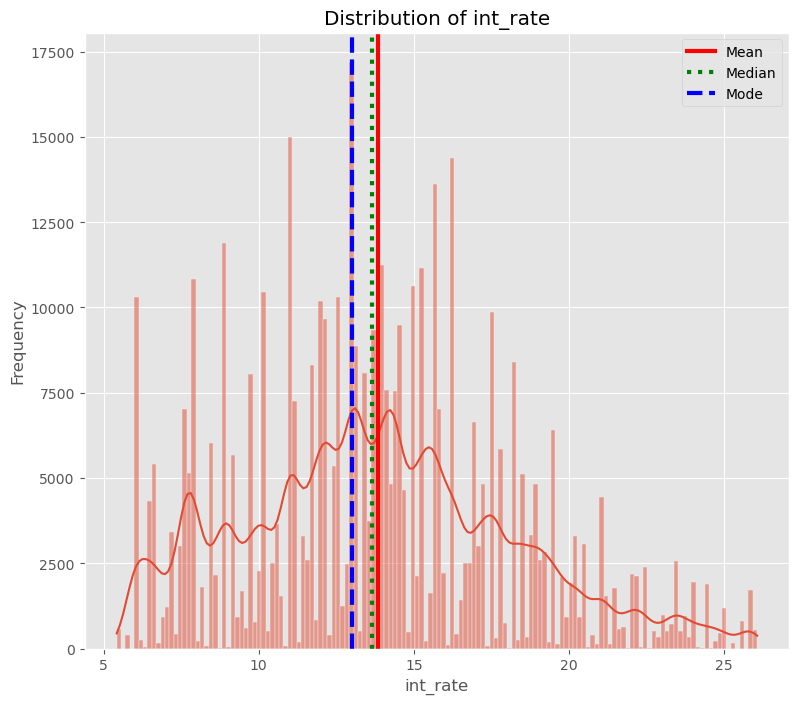

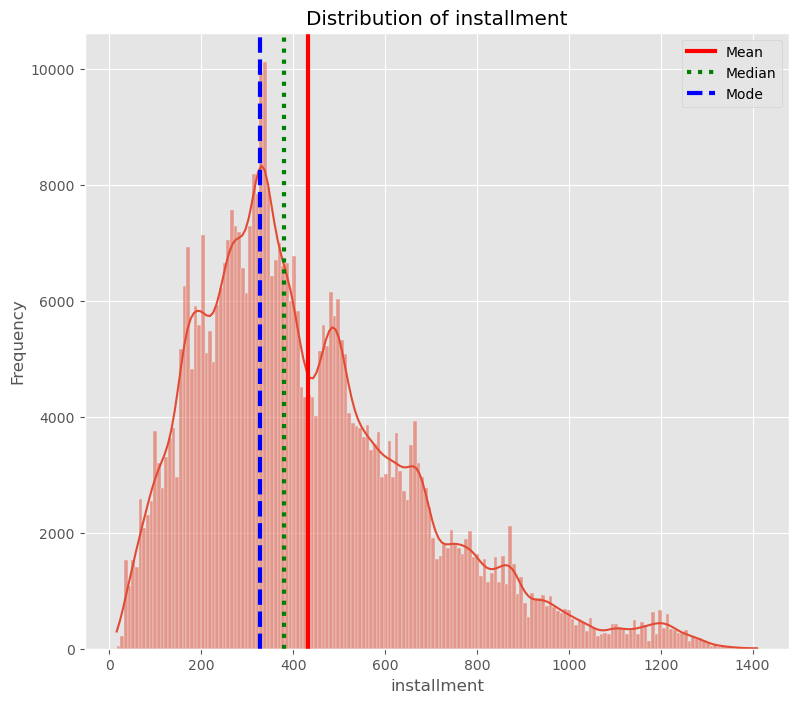

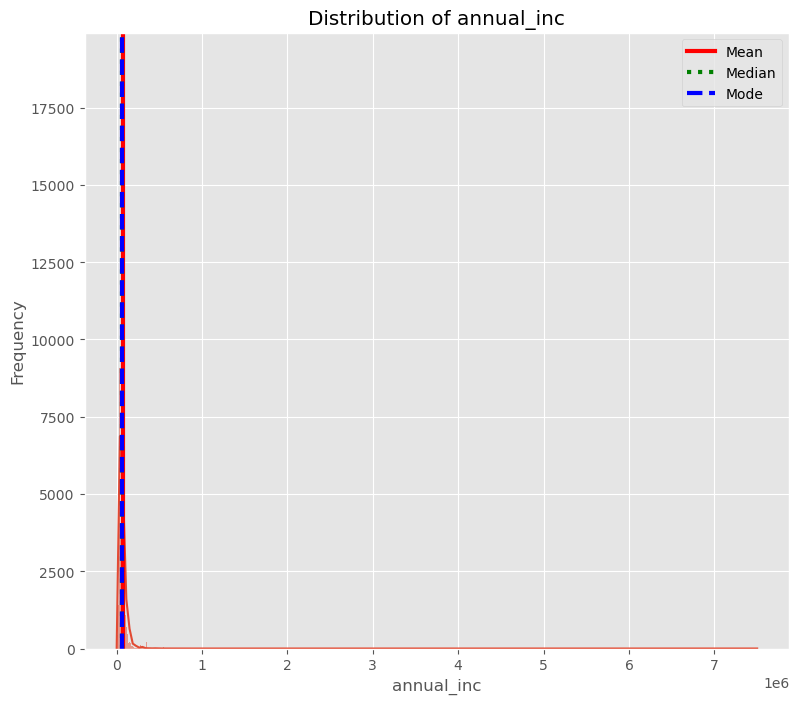

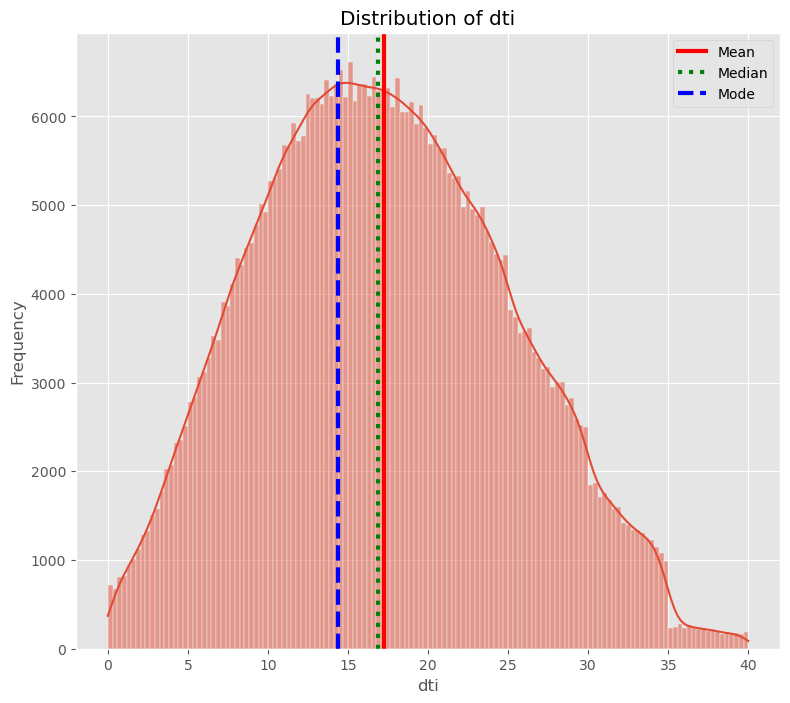

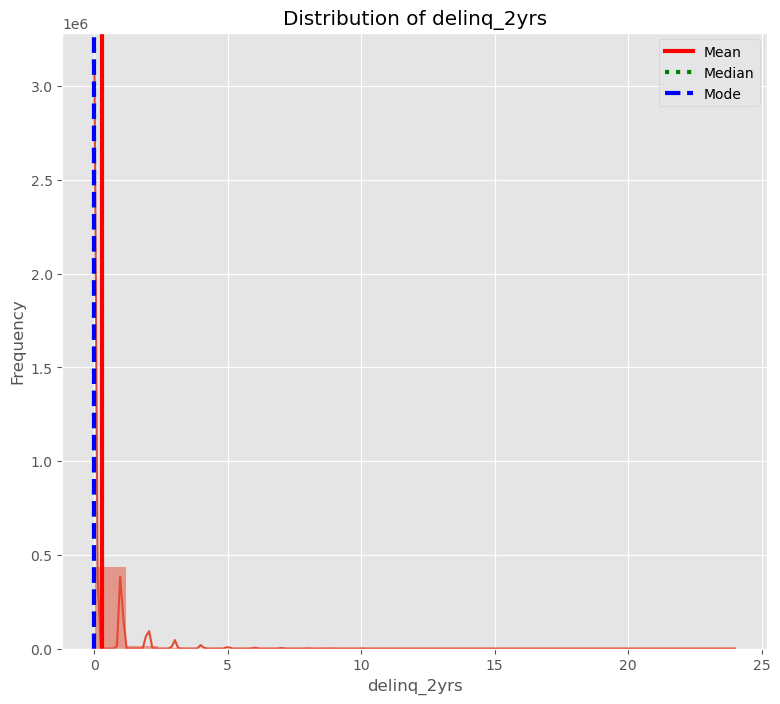

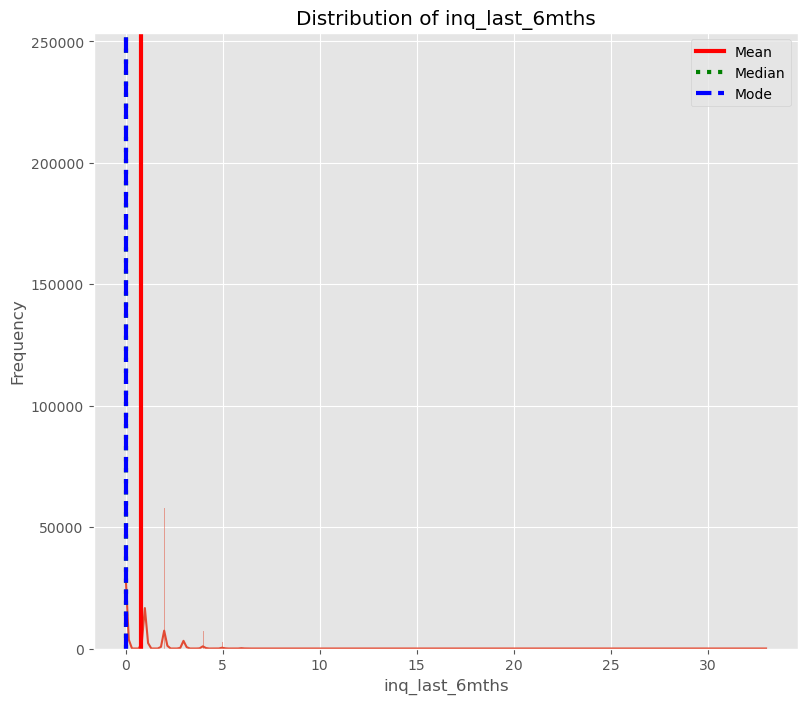

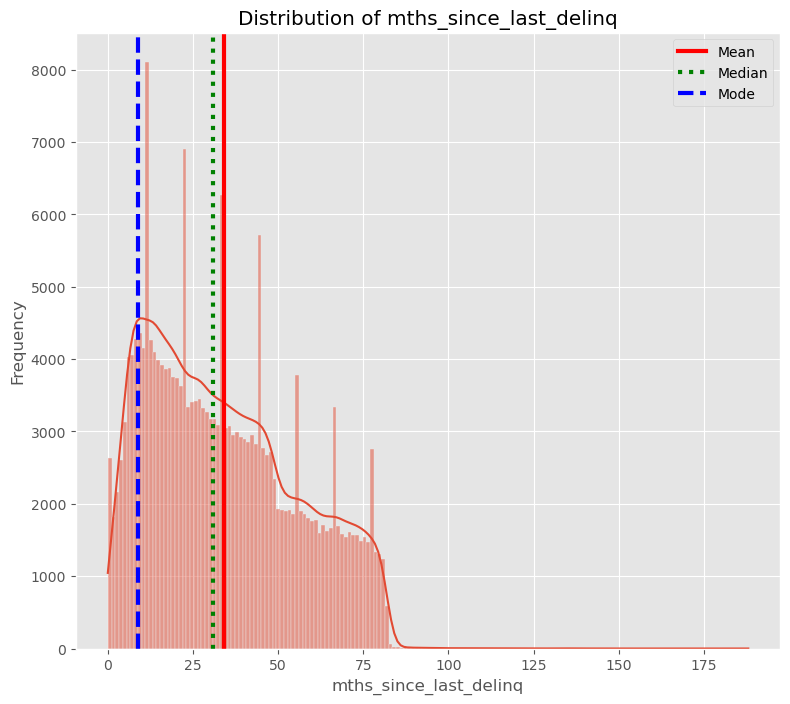

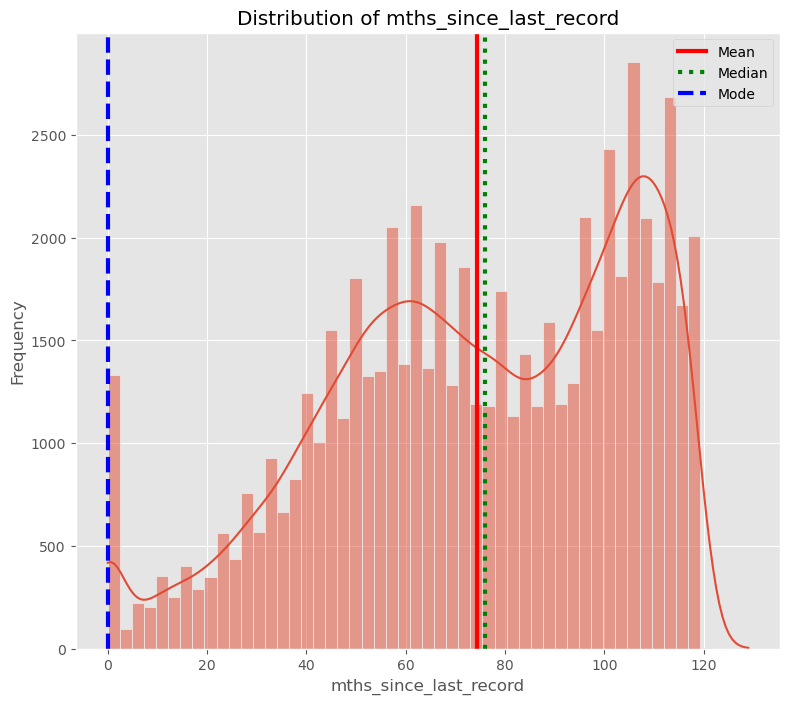

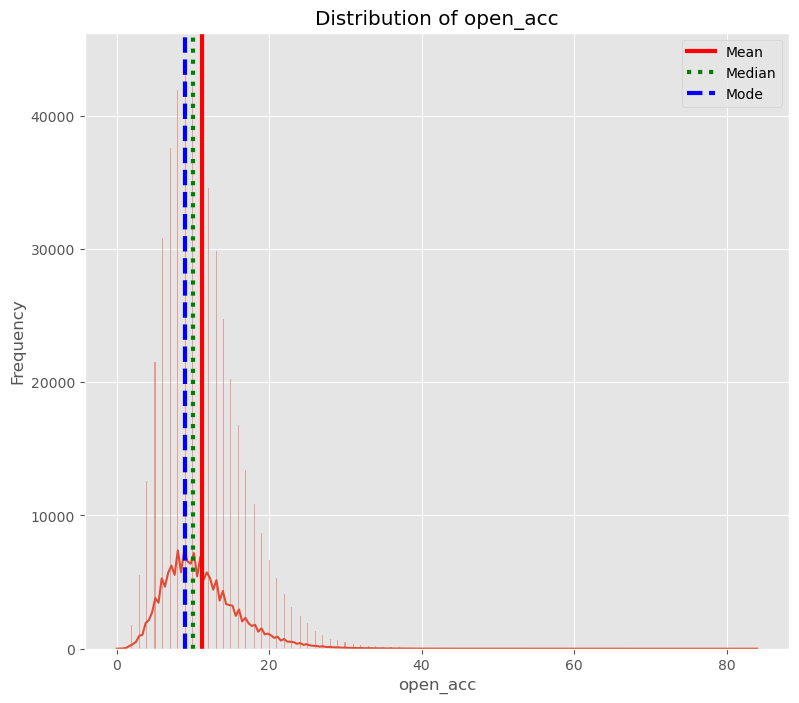

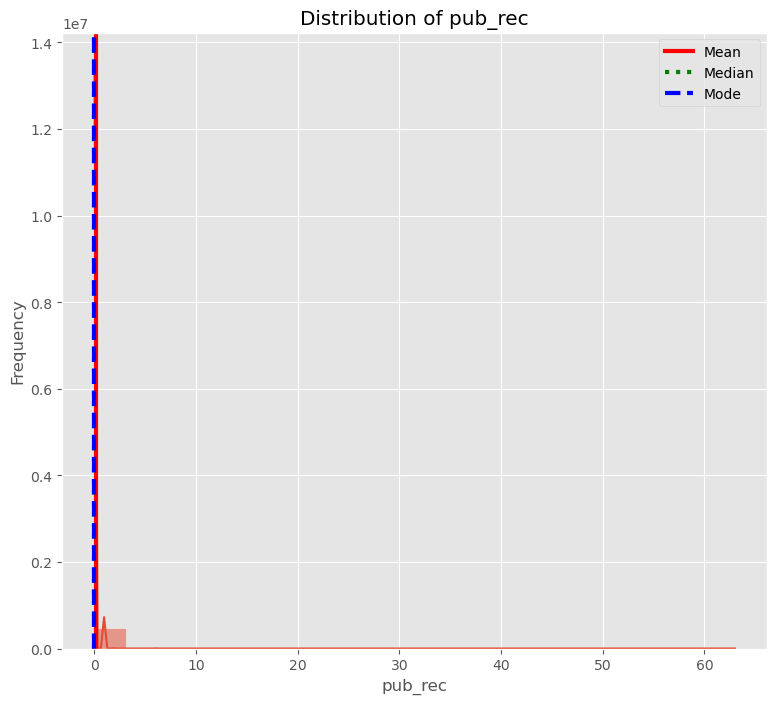

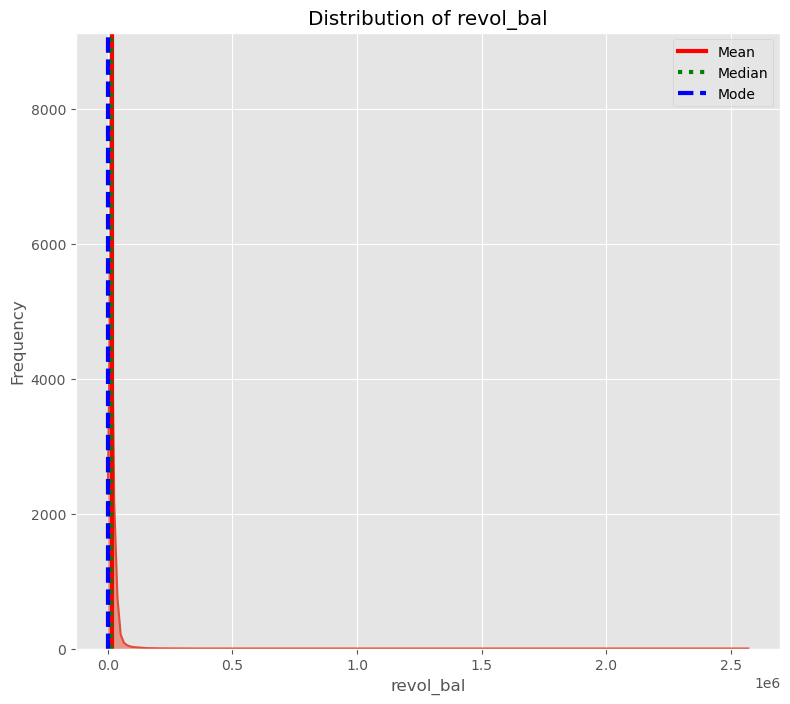

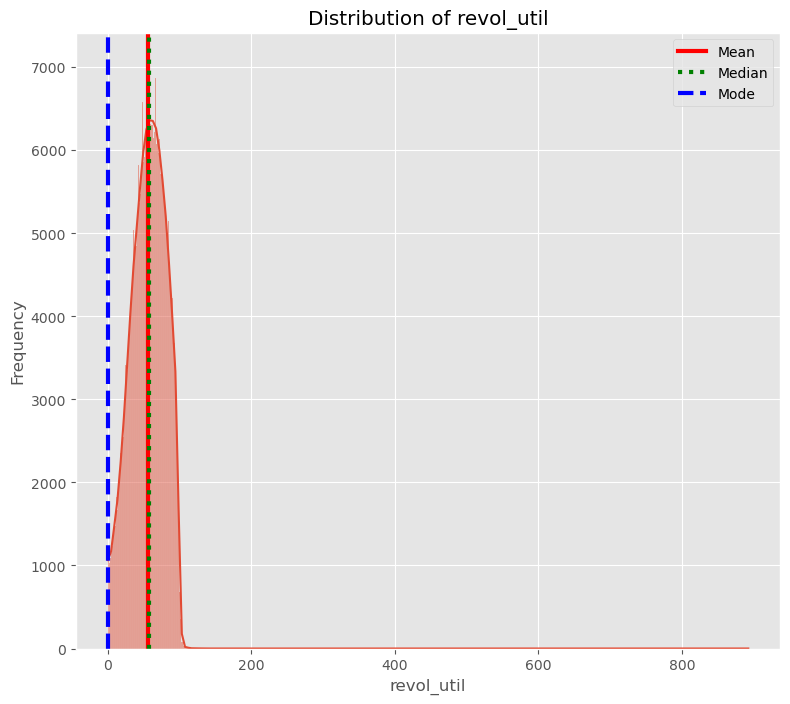

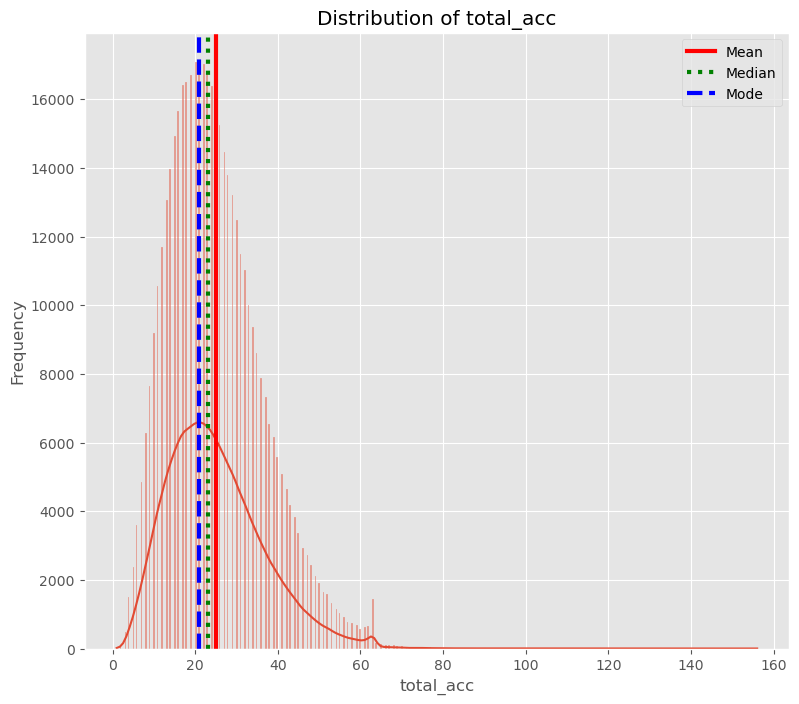

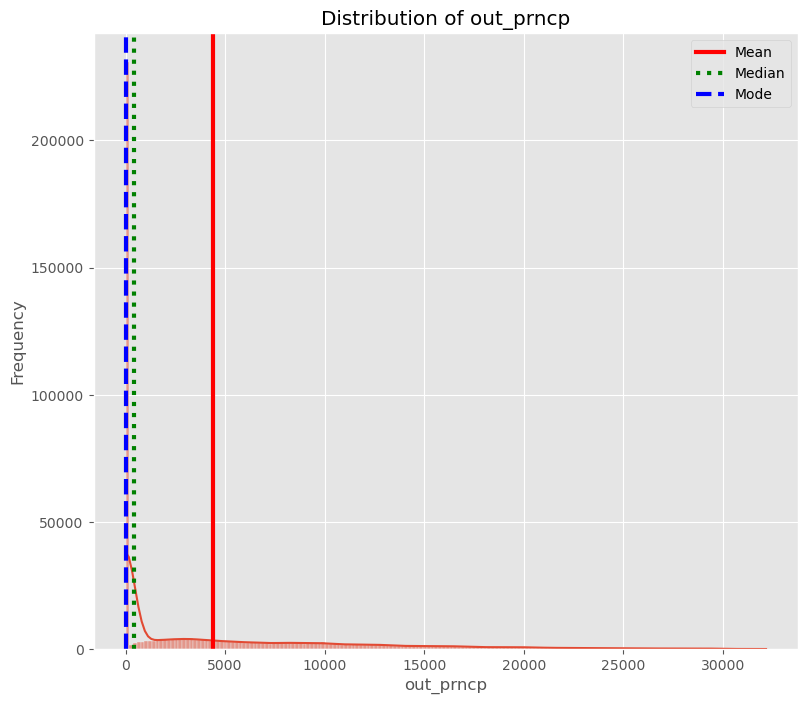

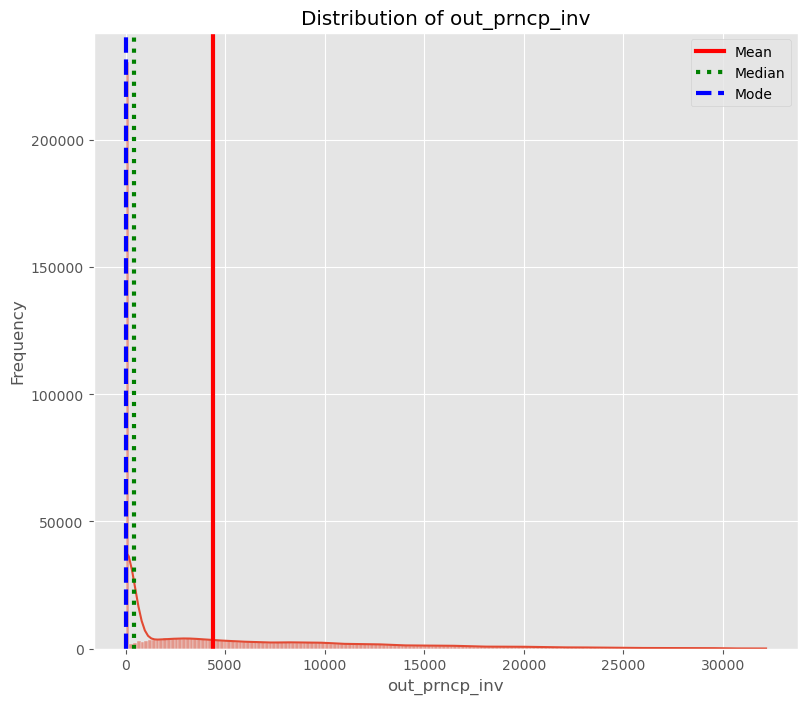

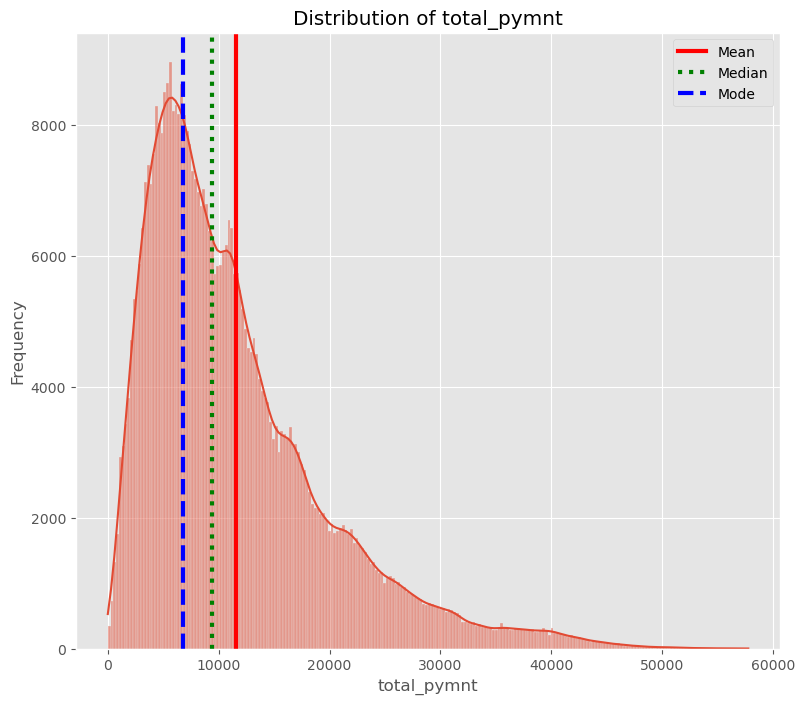

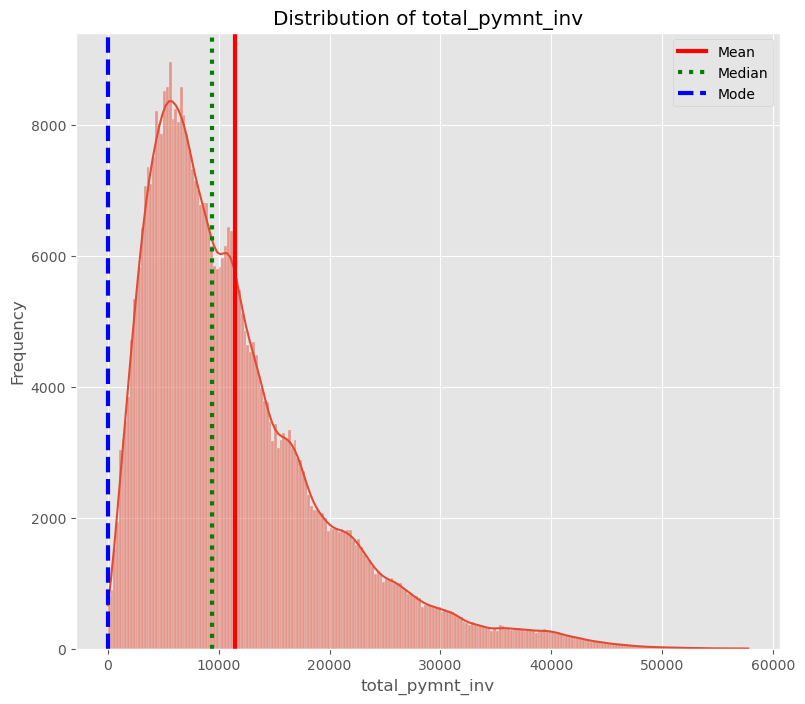

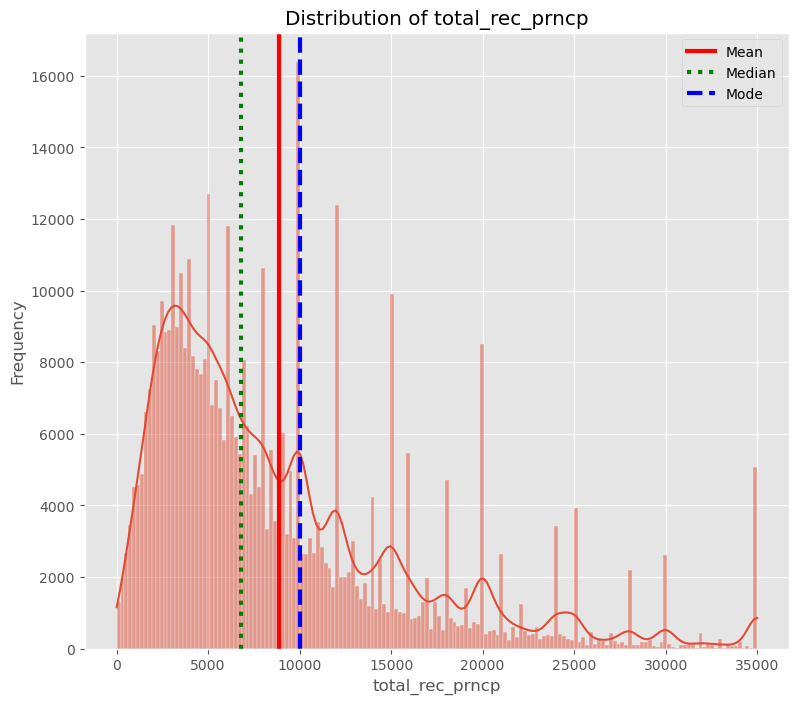

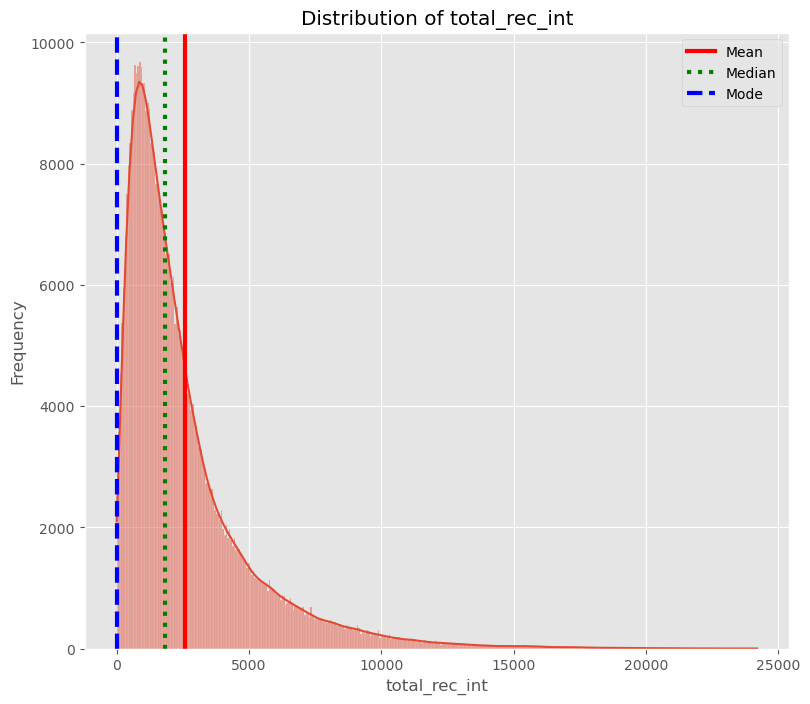

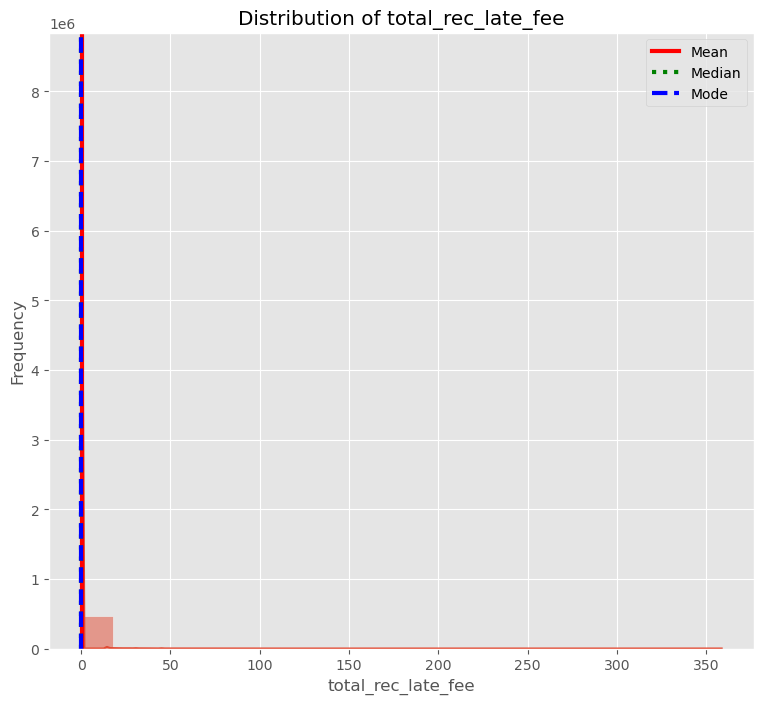

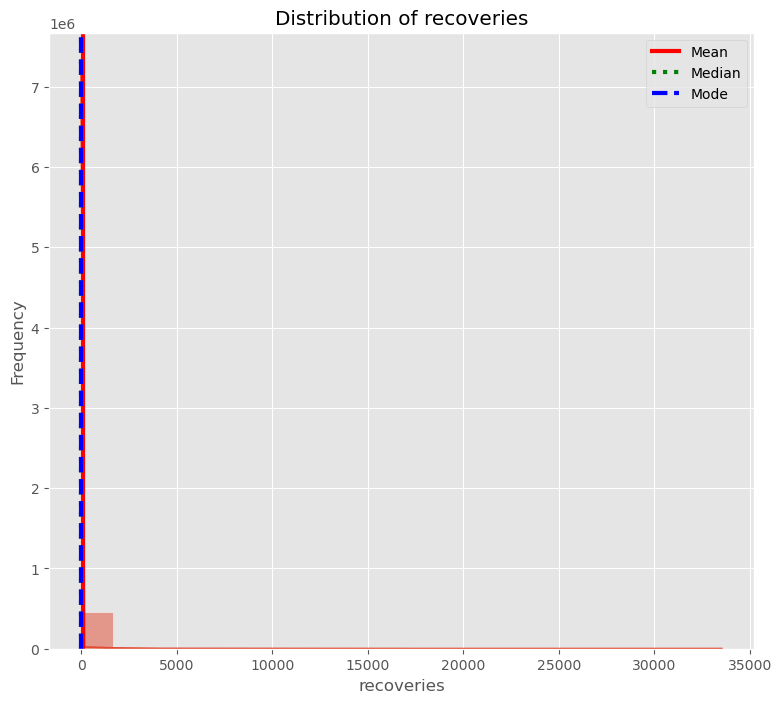

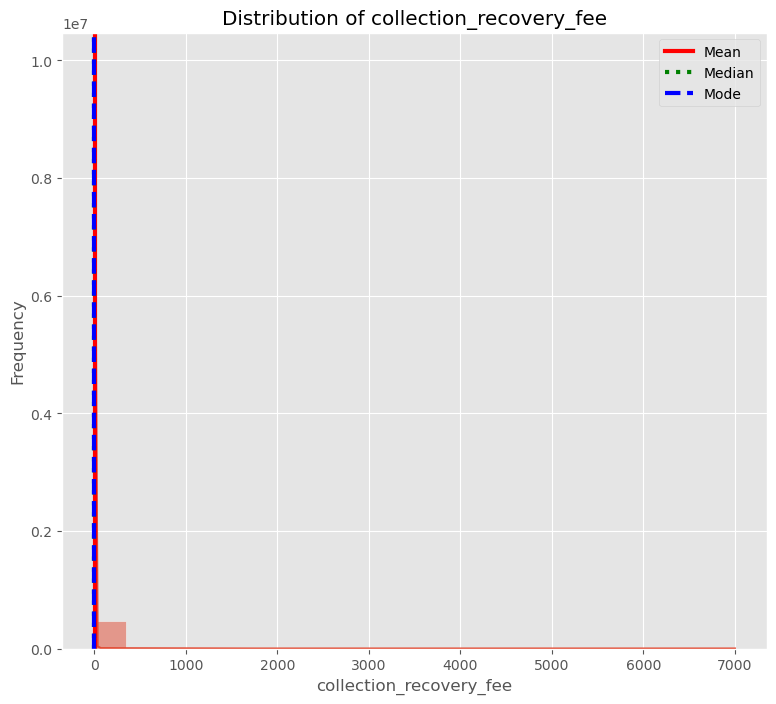

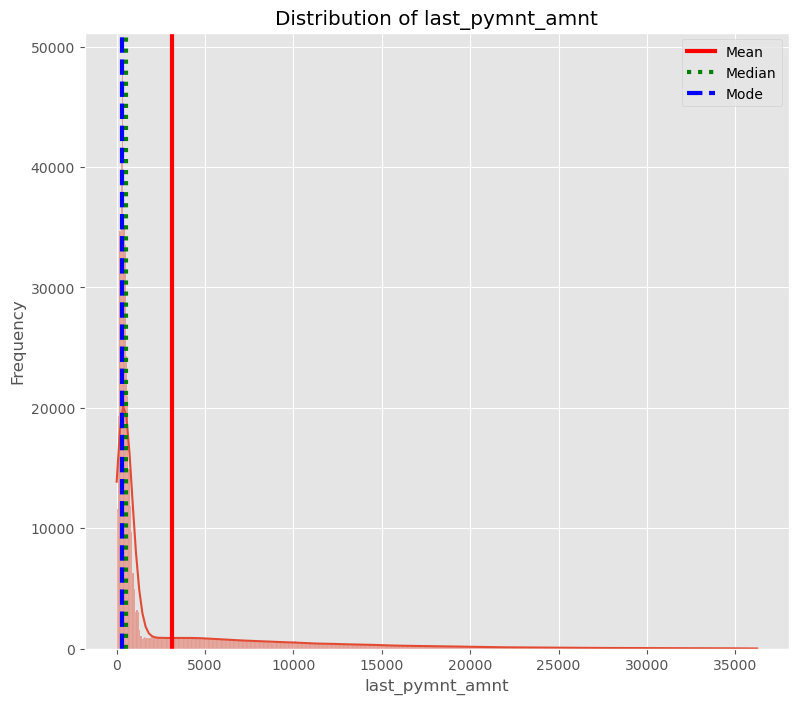

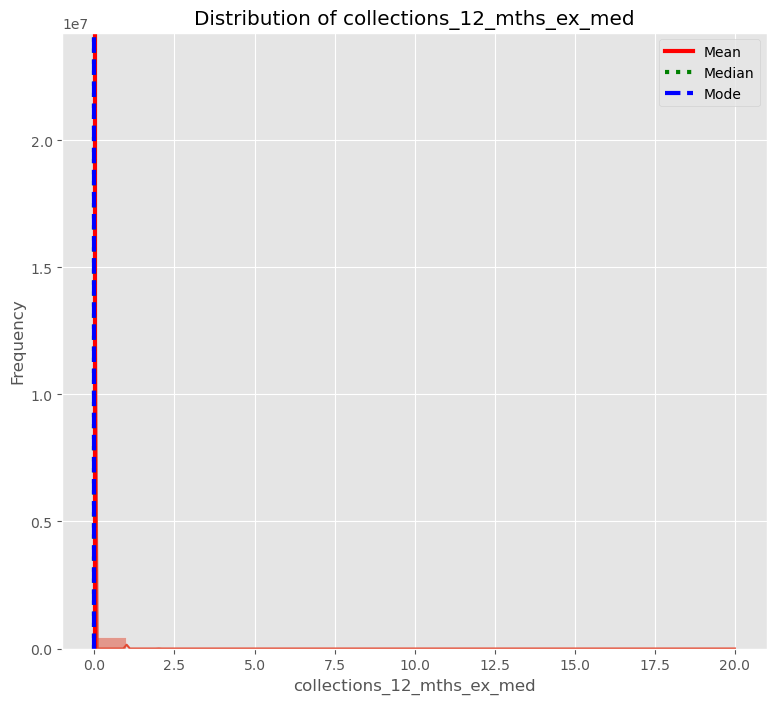

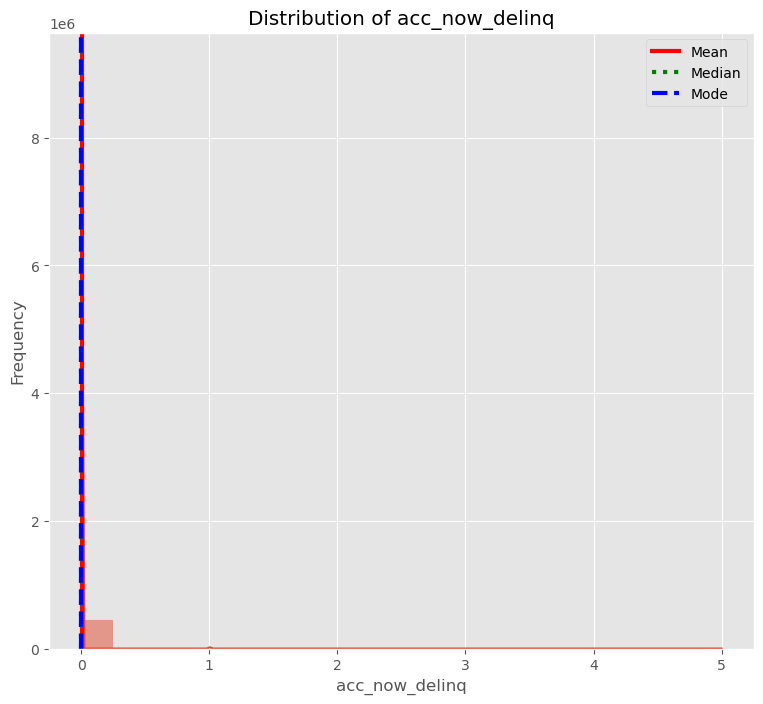

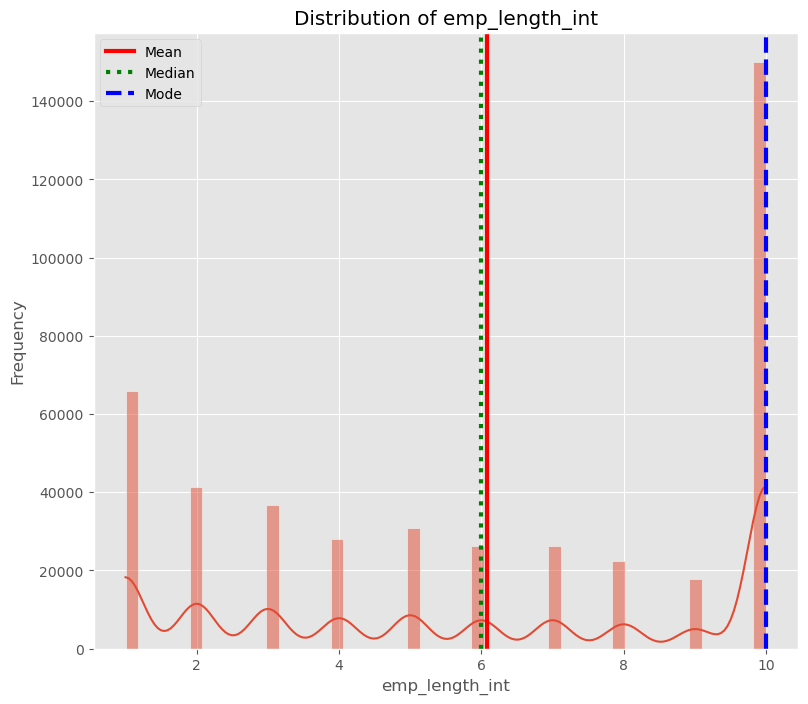

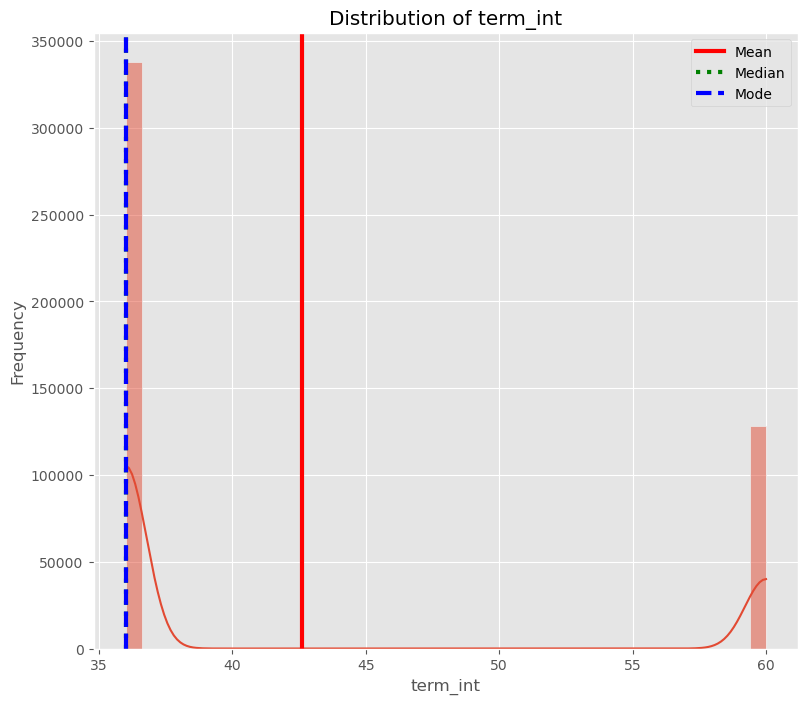

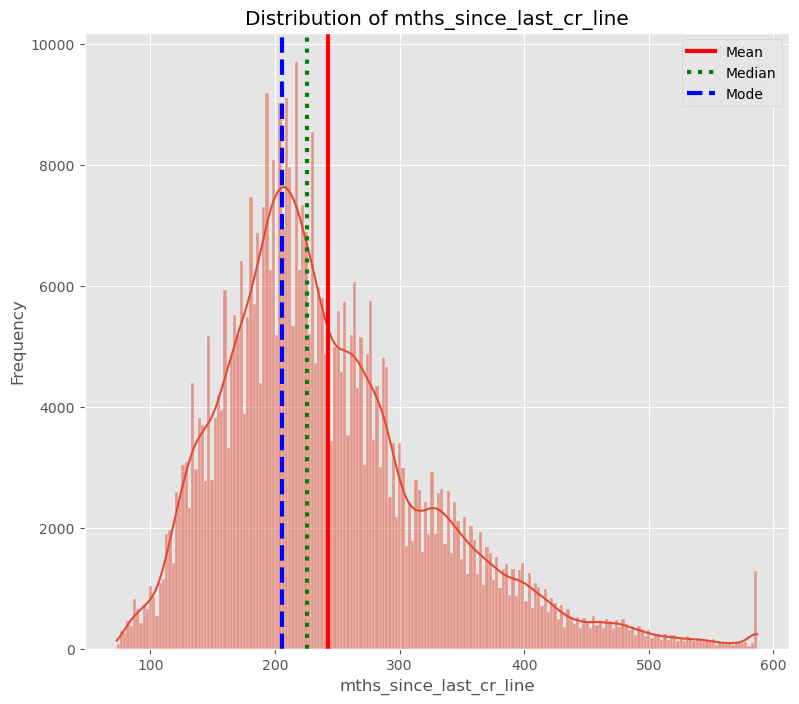

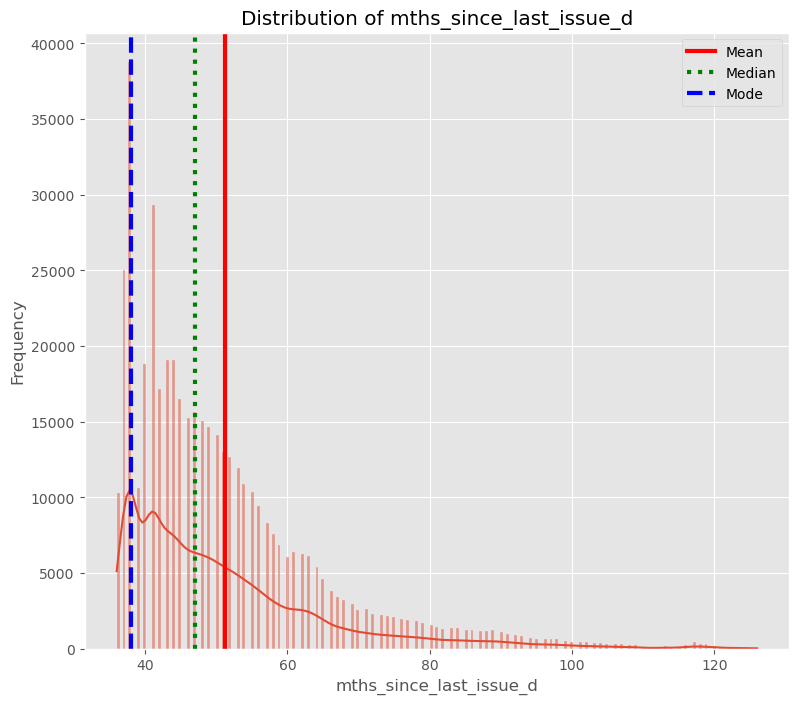

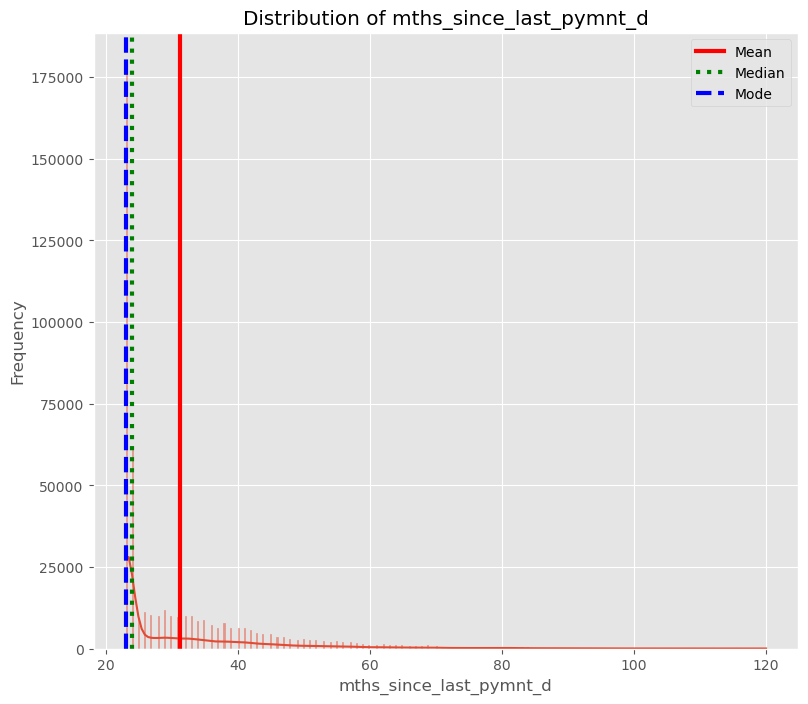

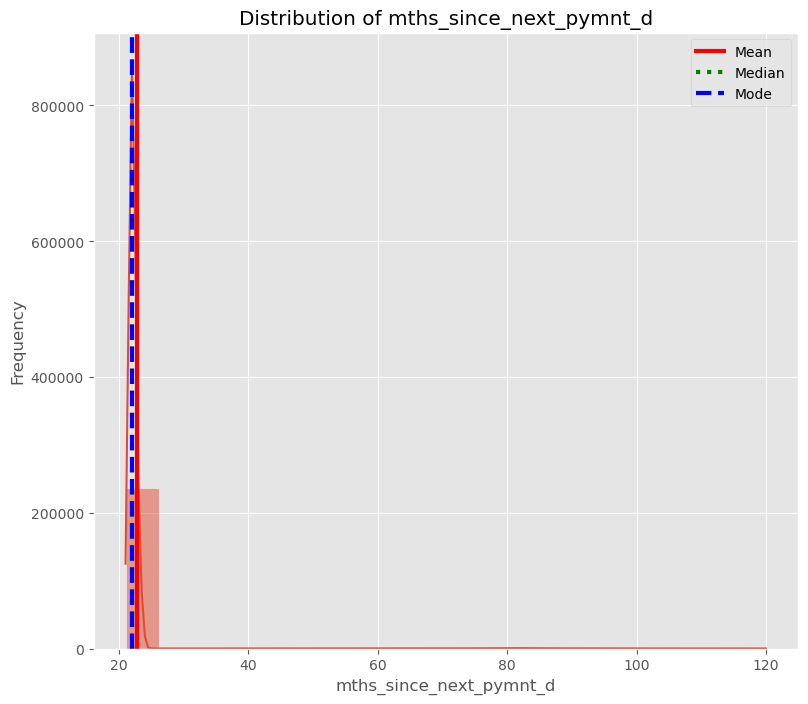

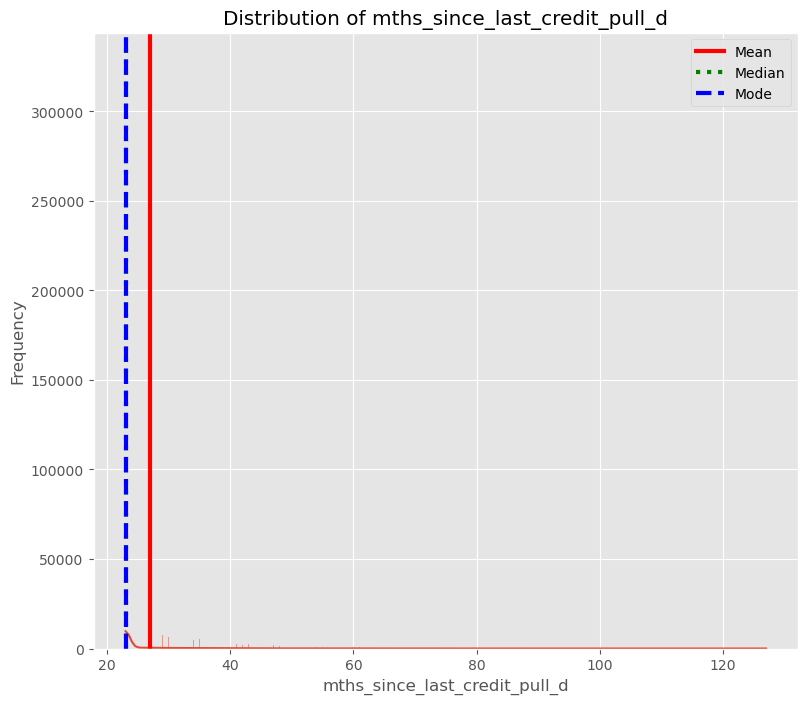

In [158]:
plt.style.use('ggplot')
for column in df.select_dtypes(include=np.number).columns.to_list():
    average = df[column].mean()
    median = df[column].median()
    mode = df[column].mode().iloc[0]
    std = df[column].std()
    
    plt.figure(figsize=(20, 8))
    plt.subplot(121)
    sns.histplot(df[column], kde=True)
    plt.axvline(average, color='r', linestyle='solid', linewidth=3, label='Mean')
    plt.axvline(median, color='g', linestyle='dotted', linewidth=3, label='Median')
    plt.axvline(mode, color='b', linestyle='dashed', linewidth=3, label='Mode')
    plt.legend()
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    
    # print('Statistic summary for column:', column)
    # print('Mean:', average)
    # print('Median:', median)
    # print('Standard Deviation:', std)
    # print('Mode:', mode)

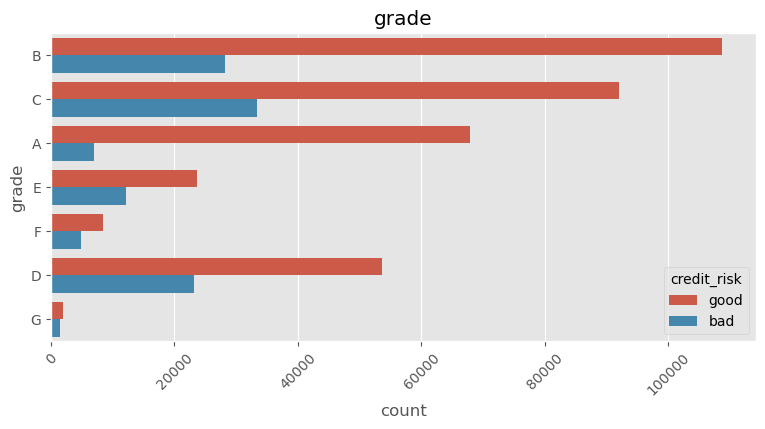

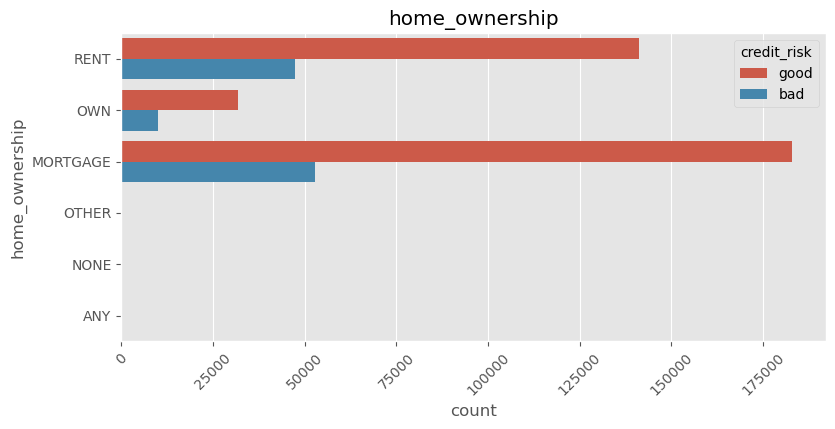

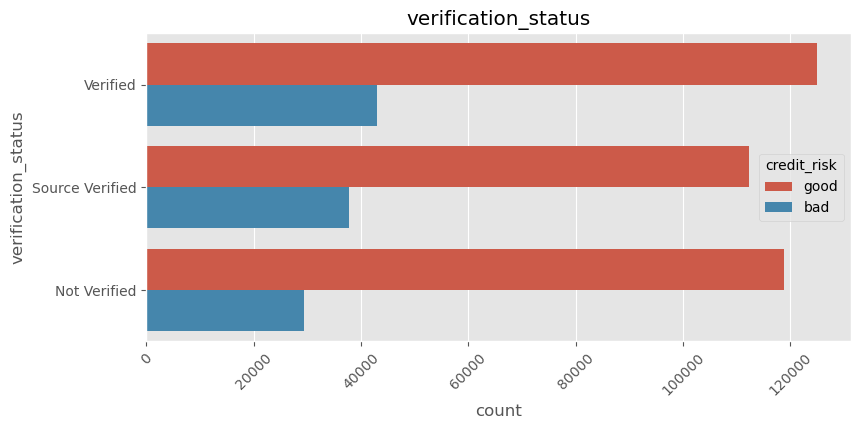

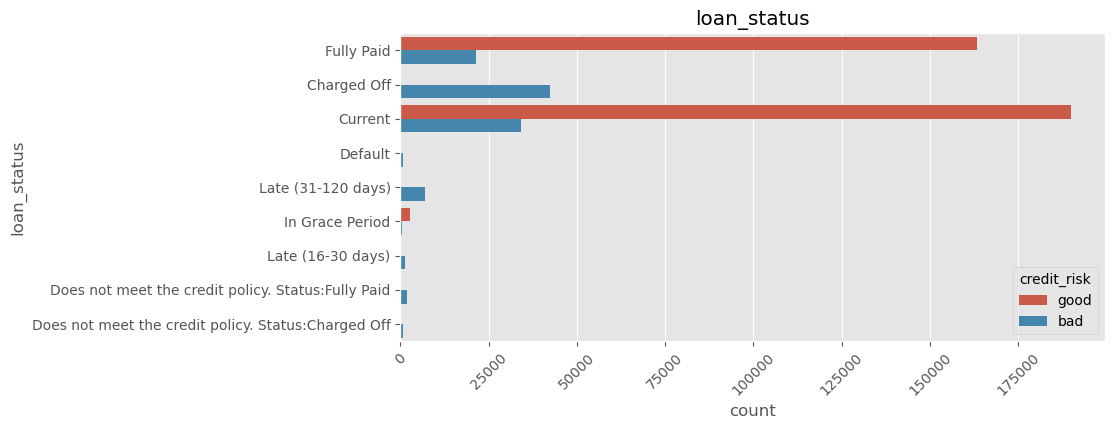

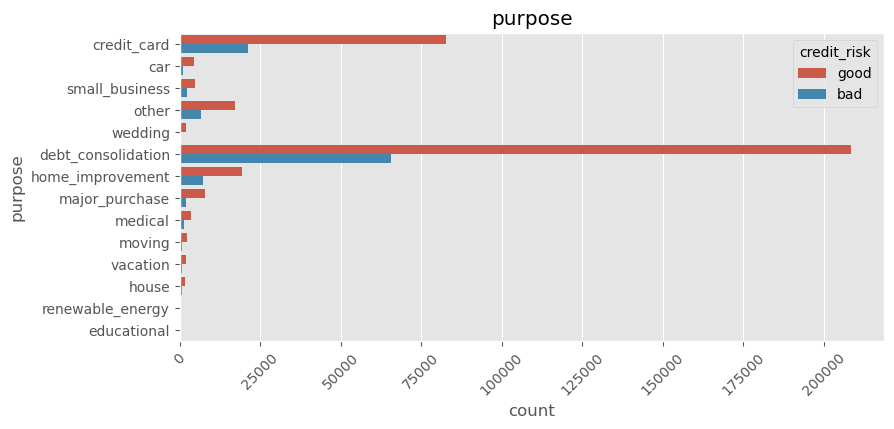

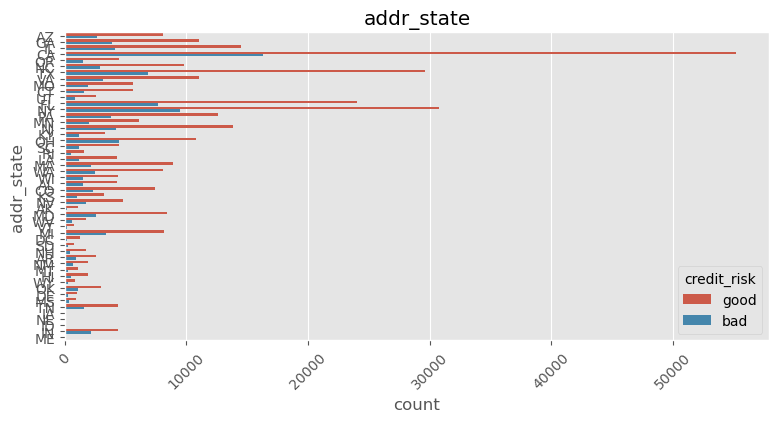

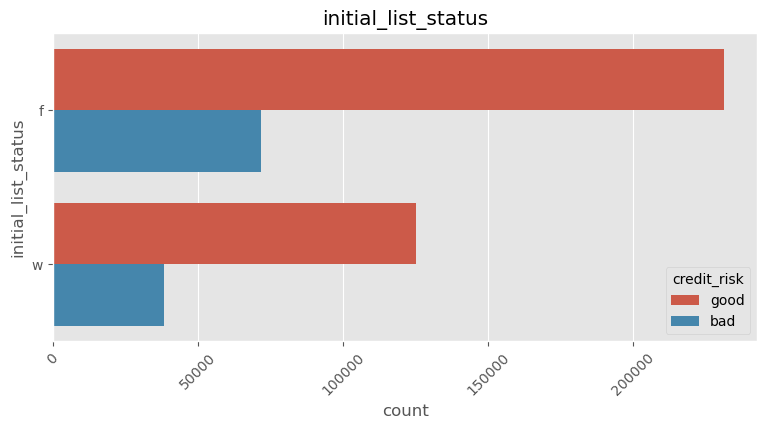

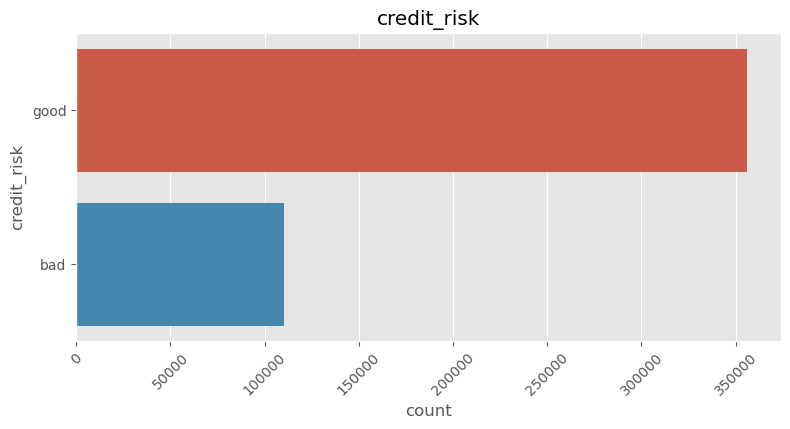

In [159]:
plt.style.use('ggplot')
for column in cat_df:
    plt.figure(figsize=(20, 4))
    plt.subplot(121)
    sns.countplot(y=df[column], hue=df['credit_risk'])
    plt.title(column)
    plt.xticks(rotation=45)

---

### <b> Data Preprocessing

In [160]:
check_missing_values = df.isnull().sum() * 100 / df.shape[0]
missing_values = check_missing_values[check_missing_values > 0].sort_values(ascending=False)

print(missing_values)

mths_since_last_record           86.566585
mths_since_last_delinq           53.690554
mths_since_next_pymnt_d          48.728567
emp_length_int                    4.505399
mths_since_last_pymnt_d           0.080637
revol_util                        0.072917
collections_12_mths_ex_med        0.031097
mths_since_last_credit_pull_d     0.009007
delinq_2yrs                       0.006219
inq_last_6mths                    0.006219
open_acc                          0.006219
total_acc                         0.006219
mths_since_last_cr_line           0.006219
annual_inc                        0.000858
dtype: float64


In [161]:
df['annual_inc'].fillna(df['annual_inc'].median(), inplace=True)
df['mths_since_last_cr_line'].fillna(0, inplace=True)


D:\R\Rtemp\ipykernel_20404\467683582.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['annual_inc'].fillna(df['annual_inc'].median(), inplace=True)
D:\R\Rtemp\ipykernel_20404\467683582.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method